Saved outputs are retained from the original experiments; they have not been regenerated with the cleaned implementation. Set data and checkpoint paths below before running.

In [ ]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "count_fm").is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
from IPython.display import display
from count_fm.experiments.pcx import sample_euler_cfg_condcountfm


In [1]:
# imports
from pathlib import Path
import sys
import os
import json
import math
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from IPython.display import display

from count_fm.models import ChunkedAdaLNTransformer
from count_fm import sample_xt, sample_rt, model_loss

In [2]:
from pathlib import Path

FIGDIR = Path("pcx_figures_pdf")
FIGDIR.mkdir(parents=True, exist_ok=True)

In [3]:
# config + path helpers

SEED = 0
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device("cpu")
print("device:", device)

SEARCH_ROOTS = [Path.cwd(), Path("/mnt/data")]
SEARCH_ROOTS = [p for i, p in enumerate(SEARCH_ROOTS) if p.exists() and p not in SEARCH_ROOTS[:i]]

def find_first_existing(filename, roots):
    for root in roots:
        cand = root / filename
        if cand.exists():
            return cand
    return None

def find_candidates(patterns, roots):
    out = []
    for root in roots:
        for pat in patterns:
            out.extend(root.rglob(pat))
    return sorted({p.resolve() for p in out if p.is_file()})

# ----------------------------
# data
# ----------------------------
DATA_FILENAME = "pcx_141208-2_bank2_XC_bin001.npz"

# ----------------------------
# checkpoints
# ----------------------------
COUNTFM_CKPT = None
BASELINE_MEAN_CKPT = None
BASELINE_POIS_CKPT = None

# ----------------------------
# load/train flags
# ----------------------------
LOAD_COUNTFM = True
DO_TRAIN_COUNTFM = False

LOAD_BASELINES = True
DO_TRAIN_BASELINES_IF_MISSING = True

# ----------------------------
# count-FM train knobs
# ----------------------------
COUNTFM_NUM_EPOCHS = 40
COUNTFM_BATCH_SIZE = 1024
COUNTFM_LR = 2e-4
COUNTFM_WEIGHT_DECAY = 1e-4
COUNTFM_P_UNCOND = 0.10
COUNTFM_EPS_T = 1e-4

# ----------------------------
# baseline train knobs
# ----------------------------
BASE_NUM_EPOCHS = 40
BASE_BATCH_SIZE = 1024
BASE_LR = 1e-3
BASE_WEIGHT_DECAY = 1e-4

# ----------------------------
# analysis config
# ----------------------------
TARGET_ODOR = 3

RESPONSE_TMIN = 0.0
RESPONSE_TMAX = 1.0
REQUIRE_ODOR_PRESENT = 1

FOCUS_GUIDE_SCALES = [1.0, 2.0]
GLOBAL_GUIDE_SCALES = [0.0, 0.5, 1.0, 1.5, 2.0]

FOCUS_REPS = 24
GLOBAL_REPS = 6

FOCUS_STEPS = 100
GLOBAL_STEPS = 60
GLOBAL_MAX_TRIALS_PER_ODOR = 2

TOPK = 10

# ----------------------------
# covariates
# ----------------------------
SELECTED_COVARIATES = ["t", "rrr_mean", "odor_present", "odor_id", "is_inhale"]
CONTINUOUS_COVARIATES = ["t", "rrr_mean"]
CATEGORICAL_COVARIATES = ["odor_present", "odor_id", "is_inhale"]
CAT_CARDINALITY_MAP = {
    "odor_present": 2,
    "odor_id": 16,
    "is_inhale": 2,
}

print("search roots:", SEARCH_ROOTS)

device: cuda
search roots: [PosixPath('/home/ganchao/Desktop/count_FM')]


In [4]:
# load data + split + flatten + feature encoding

data_path = find_first_existing(DATA_FILENAME, SEARCH_ROOTS)
if data_path is None:
    raise FileNotFoundError(f"Cannot find {DATA_FILENAME}")

d = np.load(data_path, allow_pickle=True)
X_list = list(d["X_list"])
C_list = list(d["C_list"])
meta_list = list(d["meta_list"])
C_columns = list(d["C_columns"])

col_idx = {name: i for i, name in enumerate(C_columns)}

selected_cont = [name for name in SELECTED_COVARIATES if name in CONTINUOUS_COVARIATES]
selected_cat = [name for name in SELECTED_COVARIATES if name in CATEGORICAL_COVARIATES]

cont_idx = [col_idx[name] for name in selected_cont]
cat_idx = [col_idx[name] for name in selected_cat]
cat_cardinalities = [CAT_CARDINALITY_MAP[name] for name in selected_cat]

trial_odor_ids = []
for Ci in C_list:
    Ci = np.asarray(Ci, dtype=np.float32)
    trial_odor_ids.append(int(np.rint(Ci[0, col_idx["odor_id"]])))
trial_odor_ids = np.asarray(trial_odor_ids, dtype=np.int64)

def stratified_trial_split(trial_labels, p_train=0.8, seed=0):
    rng = np.random.RandomState(seed)
    uniq = np.unique(trial_labels)
    tr, va = [], []
    for u in uniq:
        idx = np.where(trial_labels == u)[0]
        idx = rng.permutation(idx)
        if len(idx) == 1:
            tr_i, va_i = idx, np.array([], dtype=np.int64)
        else:
            n_tr = int(np.floor(p_train * len(idx)))
            n_tr = max(1, min(n_tr, len(idx) - 1))
            tr_i, va_i = idx[:n_tr], idx[n_tr:]
        tr.extend(tr_i.tolist())
        va.extend(va_i.tolist())
    return np.array(sorted(tr), dtype=np.int64), np.array(sorted(va), dtype=np.int64)

tr_trials, va_trials = stratified_trial_split(trial_odor_ids, p_train=0.8, seed=SEED)

Xtr_list = [np.clip(np.asarray(X_list[i]), 0, None).astype(np.int64) for i in tr_trials]
Xva_list = [np.clip(np.asarray(X_list[i]), 0, None).astype(np.int64) for i in va_trials]

Ctr_raw_list = [np.asarray(C_list[i], dtype=np.float32) for i in tr_trials]
Cva_raw_list = [np.asarray(C_list[i], dtype=np.float32) for i in va_trials]

Xtr = np.concatenate(Xtr_list, axis=0)
Xva = np.concatenate(Xva_list, axis=0)
Ctr_raw = np.concatenate(Ctr_raw_list, axis=0)
Cva_raw = np.concatenate(Cva_raw_list, axis=0)

mask_tr = np.isfinite(Xtr).all(axis=1) & np.isfinite(Ctr_raw).all(axis=1)
mask_va = np.isfinite(Xva).all(axis=1) & np.isfinite(Cva_raw).all(axis=1)

Xtr = Xtr[mask_tr]
Xva = Xva[mask_va]
Ctr_raw = Ctr_raw[mask_tr]
Cva_raw = Cva_raw[mask_va]

Ctr_cont = Ctr_raw[:, cont_idx].astype(np.float32) if len(cont_idx) > 0 else np.zeros((Ctr_raw.shape[0], 0), dtype=np.float32)
Cva_cont = Cva_raw[:, cont_idx].astype(np.float32) if len(cont_idx) > 0 else np.zeros((Cva_raw.shape[0], 0), dtype=np.float32)

Ctr_cat = np.rint(Ctr_raw[:, cat_idx]).astype(np.int64) if len(cat_idx) > 0 else np.zeros((Ctr_raw.shape[0], 0), dtype=np.int64)
Cva_cat = np.rint(Cva_raw[:, cat_idx]).astype(np.int64) if len(cat_idx) > 0 else np.zeros((Cva_raw.shape[0], 0), dtype=np.int64)

def fit_feature_encoder(C_cont_train, C_cat_train, cat_cardinalities):
    if C_cont_train.shape[1] > 0:
        cont_mean = C_cont_train.mean(axis=0, keepdims=True)
        cont_std = C_cont_train.std(axis=0, keepdims=True)
        cont_std = np.where(cont_std < 1e-6, 1.0, cont_std)
    else:
        cont_mean = np.zeros((1, 0), dtype=np.float32)
        cont_std = np.ones((1, 0), dtype=np.float32)
    return {
        "cont_mean": cont_mean.astype(np.float32),
        "cont_std": cont_std.astype(np.float32),
        "cat_cardinalities": list(cat_cardinalities),
    }

def transform_features(C_cont, C_cat, enc):
    parts = [np.ones((C_cont.shape[0], 1), dtype=np.float32)]
    if C_cont.shape[1] > 0:
        z = (C_cont - enc["cont_mean"]) / enc["cont_std"]
        parts.append(z.astype(np.float32))
    for j, K in enumerate(enc["cat_cardinalities"]):
        oh = np.zeros((C_cat.shape[0], K), dtype=np.float32)
        idx = np.clip(C_cat[:, j], 0, K - 1)
        oh[np.arange(C_cat.shape[0]), idx] = 1.0
        parts.append(oh)
    return np.concatenate(parts, axis=1)

feature_enc = fit_feature_encoder(Ctr_cont, Ctr_cat, cat_cardinalities)
Phi_tr = transform_features(Ctr_cont, Ctr_cat, feature_enc)
Phi_va = transform_features(Cva_cont, Cva_cat, feature_enc)

Xtr_t = torch.from_numpy(Xtr).float()
Xva_t = torch.from_numpy(Xva).float()
Ctr_cont_t = torch.from_numpy(Ctr_cont).float()
Cva_cont_t = torch.from_numpy(Cva_cont).float()
Ctr_cat_t = torch.from_numpy(Ctr_cat).long()
Cva_cat_t = torch.from_numpy(Cva_cat).long()

Phi_tr_t = torch.from_numpy(Phi_tr).float()
Phi_va_t = torch.from_numpy(Phi_va).float()

d_neuron = Xtr.shape[1]
x0_poisson_rate = float(Xtr.mean())
C_max_data = int(Xtr.max()) + 2

print("data path:", data_path)
print("n_train_trials:", len(tr_trials), "n_val_trials:", len(va_trials))
print("Xtr:", Xtr.shape, "Xva:", Xva.shape)
print("d_neuron:", d_neuron)

data path: /home/ganchao/Desktop/count_FM/pcx_141208-2_bank2_XC_bin001.npz
n_train_trials: 384 n_val_trials: 96
Xtr: (76800, 84) Xva: (19200, 84)
d_neuron: 84


In [5]:
from count_fm.models.pcx import MeanMLP, PoissonMLP, CondCountFMNet, CondCountFMNet_MLP
from count_fm.experiments.pcx_evaluation import (
    extract_state_dict, extract_model_kwargs, infer_countfm_architecture,
    build_countfm_model_from_blob, load_model_state, train_supervised, train_countfm,
)

In [6]:
# load / train models

base_train_ds = TensorDataset(Phi_tr_t, Xtr_t)
base_val_ds = TensorDataset(Phi_va_t, Xva_t)
base_train_loader = DataLoader(base_train_ds, batch_size=BASE_BATCH_SIZE, shuffle=True, drop_last=True)
base_val_loader = DataLoader(base_val_ds, batch_size=BASE_BATCH_SIZE, shuffle=False, drop_last=False)

if BASELINE_MEAN_CKPT is None:
    BASELINE_MEAN_CKPT = find_first_existing("pcx_mean_mlp.pt", SEARCH_ROOTS)

if BASELINE_POIS_CKPT is None:
    BASELINE_POIS_CKPT = find_first_existing("pcx_pois_mlp.pt", SEARCH_ROOTS)

if COUNTFM_CKPT is None:
    preferred = [
        "cond_countfm_cfg_ckpt_all_poi_meanRate_trial_level_split_mlp.pt",
        "cond_countfm_cfg_ckpt_all_poi_meanRate_trial_level_split.pt",
        "pcx_countfm_mlp.pt",
    ]
    for name in preferred:
        COUNTFM_CKPT = find_first_existing(name, SEARCH_ROOTS)
        if COUNTFM_CKPT is not None:
            break

print("BASELINE_MEAN_CKPT:", BASELINE_MEAN_CKPT)
print("BASELINE_POIS_CKPT:", BASELINE_POIS_CKPT)
print("COUNTFM_CKPT:", COUNTFM_CKPT)

# nonlinear mean baseline
mean_model = MeanMLP(in_dim=Phi_tr.shape[1], out_dim=d_neuron, hidden=128, depth=3)
if LOAD_BASELINES and BASELINE_MEAN_CKPT is not None and Path(BASELINE_MEAN_CKPT).exists():
    mean_model = load_model_state(mean_model, BASELINE_MEAN_CKPT)
else:
    if not DO_TRAIN_BASELINES_IF_MISSING:
        raise FileNotFoundError("Mean baseline checkpoint missing.")
    mean_model = train_supervised(
        mean_model,
        base_train_loader,
        base_val_loader,
        loss_fn=nn.MSELoss(),
        lr=BASE_LR,
        weight_decay=BASE_WEIGHT_DECAY,
        num_epochs=BASE_NUM_EPOCHS,
    )
    torch.save({"state_dict": mean_model.state_dict()}, "pcx_mean_mlp.pt")
mean_model = mean_model.to(device).eval()

# nonlinear Poisson baseline
pois_model = PoissonMLP(in_dim=Phi_tr.shape[1], out_dim=d_neuron, hidden=128, depth=3)
pois_loss_fn = lambda pred, target: F.poisson_nll_loss(pred, target, log_input=False, full=True)
if LOAD_BASELINES and BASELINE_POIS_CKPT is not None and Path(BASELINE_POIS_CKPT).exists():
    pois_model = load_model_state(pois_model, BASELINE_POIS_CKPT)
else:
    if not DO_TRAIN_BASELINES_IF_MISSING:
        raise FileNotFoundError("Poisson baseline checkpoint missing.")
    pois_model = train_supervised(
        pois_model,
        base_train_loader,
        base_val_loader,
        loss_fn=pois_loss_fn,
        lr=BASE_LR,
        weight_decay=BASE_WEIGHT_DECAY,
        num_epochs=BASE_NUM_EPOCHS,
    )
    torch.save({"state_dict": pois_model.state_dict()}, "pcx_pois_mlp.pt")
pois_model = pois_model.to(device).eval()

# count-FM
if LOAD_COUNTFM and COUNTFM_CKPT is not None and Path(COUNTFM_CKPT).exists():
    blob = torch.load(COUNTFM_CKPT, map_location="cpu")
    countfm_model, countfm_arch, countfm_model_kwargs = build_countfm_model_from_blob(
        blob,
        d=d_neuron,
        cont_dim=Ctr_cont.shape[1],
        cat_cardinalities=cat_cardinalities,
        eps_time=COUNTFM_EPS_T,
    )
    train_meta = blob.get("train_meta", {}) if isinstance(blob, dict) else {}
    C_max = int(blob.get("C_max", train_meta.get("C_max", C_max_data))) if isinstance(blob, dict) else C_max_data
    x0_poisson_rate = float(blob.get("x0_poisson_rate", train_meta.get("x0_poisson_rate", x0_poisson_rate))) if isinstance(blob, dict) else x0_poisson_rate
elif DO_TRAIN_COUNTFM:
    countfm_model = CondCountFMNet_MLP(
        d=d_neuron,
        cont_dim=Ctr_cont.shape[1],
        cat_cardinalities=cat_cardinalities,
        emb_dim=16,
        hidden=128,
        depth=3,
        log_cap=5.0,
        eps_time=COUNTFM_EPS_T,
    )
    countfm_model = train_countfm(
        countfm_model,
        Xtr_t, Ctr_cont_t, Ctr_cat_t,
        Xva_t, Cva_cont_t, Cva_cat_t,
        x0_poisson_rate=x0_poisson_rate,
        batch_size=COUNTFM_BATCH_SIZE,
        lr=COUNTFM_LR,
        weight_decay=COUNTFM_WEIGHT_DECAY,
        num_epochs=COUNTFM_NUM_EPOCHS,
        p_uncond=COUNTFM_P_UNCOND,
        eps_t=COUNTFM_EPS_T,
    )
    C_max = C_max_data
    countfm_arch = "mlp"
    torch.save(
        {
            "state_dict": countfm_model.state_dict(),
            "C_max": C_max,
            "x0_poisson_rate": x0_poisson_rate,
        },
        "pcx_countfm_mlp.pt",
    )
else:
    raise FileNotFoundError("count-FM checkpoint missing and DO_TRAIN_COUNTFM=False.")

countfm_model = countfm_model.to(device).eval()

print("mean baseline ready")
print("poisson baseline ready")
print("count-FM ready")
print("count-FM architecture:", countfm_arch)
print("C_max:", C_max)
print("x0_poisson_rate:", x0_poisson_rate)

BASELINE_MEAN_CKPT: /home/ganchao/Desktop/count_FM/pcx_mean_mlp.pt
BASELINE_POIS_CKPT: /home/ganchao/Desktop/count_FM/pcx_pois_mlp.pt
COUNTFM_CKPT: /home/ganchao/Desktop/count_FM/cond_countfm_cfg_ckpt_all_poi_meanRate_trial_level_split_mlp.pt
mean baseline ready
poisson baseline ready
count-FM ready
count-FM architecture: mlp
C_max: 5
x0_poisson_rate: 0.01494109623015873


In [7]:
# analysis helpers

def split_trial_covariates(C_trial):
    C_trial = np.asarray(C_trial, dtype=np.float32)
    c_cont = C_trial[:, cont_idx].astype(np.float32) if len(cont_idx) > 0 else np.zeros((C_trial.shape[0], 0), dtype=np.float32)
    c_cat = np.rint(C_trial[:, cat_idx]).astype(np.int64) if len(cat_idx) > 0 else np.zeros((C_trial.shape[0], 0), dtype=np.int64)
    return c_cont, c_cat

def response_mask(C_trial):
    C_trial = np.asarray(C_trial, dtype=np.float32)
    t = C_trial[:, col_idx["t"]]
    odor_present = np.rint(C_trial[:, col_idx["odor_present"]]).astype(np.int64)
    mask = (t >= RESPONSE_TMIN) & (t < RESPONSE_TMAX)
    if REQUIRE_ODOR_PRESENT is not None:
        mask = mask & (odor_present == int(REQUIRE_ODOR_PRESENT))
    return mask

def trial_response_vector(X_trial, C_trial):
    m = response_mask(C_trial)
    return np.asarray(X_trial)[m].sum(axis=0).astype(np.float32)

def trial_total_count(X_trial, C_trial):
    return float(trial_response_vector(X_trial, C_trial).sum())

def baseline_mean_trial(C_trial):
    c_cont, c_cat = split_trial_covariates(C_trial)
    Phi = transform_features(c_cont, c_cat, feature_enc)
    with torch.no_grad():
        x = torch.from_numpy(Phi).float().to(device)
        y = mean_model(x).cpu().numpy()
    return y.astype(np.float32)

def baseline_pois_trial(C_trial, n_rep):
    c_cont, c_cat = split_trial_covariates(C_trial)
    Phi = transform_features(c_cont, c_cat, feature_enc)
    with torch.no_grad():
        x = torch.from_numpy(Phi).float().to(device)
        lam = pois_model(x).cpu().numpy()
    out = np.random.poisson(np.clip(lam, 1e-8, None), size=(n_rep,) + lam.shape)
    return out.astype(np.int64)

@torch.no_grad()
def sample_countfm_trial(C_trial, n_rep, guidance_scale, n_step):
    c_cont_np, c_cat_np = split_trial_covariates(C_trial)
    c_cont = torch.from_numpy(c_cont_np).float().to(device)
    c_cat = torch.from_numpy(c_cat_np).long().to(device)

    c_cont = c_cont.repeat((n_rep, 1))
    c_cat = c_cat.repeat((n_rep, 1))

    xt = torch.poisson(torch.full((c_cont.shape[0], d_neuron), float(x0_poisson_rate), device=device, dtype=torch.float32))
    xt = sample_euler_cfg_condcountfm(
        countfm_model, n_step, xt, c_cont, c_cat,
        guidance_scale=guidance_scale, eps_t=COUNTFM_EPS_T,
    )

    return xt.cpu().numpy().astype(np.int64).reshape(n_rep, c_cont_np.shape[0], d_neuron)


def get_focus_and_global_trial_indices():
    val_odor_ids = trial_odor_ids[va_trials]
    focus_local_idx = np.where(val_odor_ids == TARGET_ODOR)[0]

    rng = np.random.default_rng(SEED)
    global_local_idx = []
    for odor in np.unique(val_odor_ids):
        idx = np.where(val_odor_ids == odor)[0]
        if len(idx) <= GLOBAL_MAX_TRIALS_PER_ODOR:
            picked = idx
        else:
            picked = np.sort(rng.choice(idx, size=GLOBAL_MAX_TRIALS_PER_ODOR, replace=False))
        global_local_idx.extend(picked.tolist())
    global_local_idx = np.array(sorted(global_local_idx), dtype=np.int64)
    return focus_local_idx, global_local_idx

def build_bank(local_idx_array, guide_scales, n_rep, n_step):
    out = []
    for local_i in local_idx_array:
        X_real = np.asarray(Xva_list[local_i]).astype(np.int64)
        C_trial = np.asarray(Cva_raw_list[local_i]).astype(np.float32)
        odor_i = int(np.rint(C_trial[0, col_idx["odor_id"]]))

        rec = {
            "local_i": int(local_i),
            "odor": odor_i,
            "C": C_trial,
            "X_real": X_real,
            "X_mean": baseline_mean_trial(C_trial),
            "X_pois": baseline_pois_trial(C_trial, n_rep),
            "X_countfm": {},
        }
        for w in guide_scales:
            rec["X_countfm"][float(w)] = sample_countfm_trial(C_trial, n_rep, float(w), n_step)
        out.append(rec)
    return out

def _aggregate_covariates_from_records(record_list):
    Cs = [np.asarray(r["C"], dtype=np.float32) for r in record_list]
    t = Cs[0][:, col_idx["t"]].astype(np.float32)

    rrr_all = np.stack([C[:, col_idx["rrr_mean"]].astype(np.float32) for C in Cs], axis=0)
    odor_all = np.stack([np.rint(C[:, col_idx["odor_present"]]).astype(np.float32) for C in Cs], axis=0)
    inhale_all = np.stack([np.rint(C[:, col_idx["is_inhale"]]).astype(np.float32) for C in Cs], axis=0)

    odor_id_vals = [int(np.rint(C[0, col_idx["odor_id"]])) for C in Cs]
    odor_id_unique = sorted(set(odor_id_vals))

    return {
        "t": t,
        "rrr_all": rrr_all,
        "rrr_mean": rrr_all.mean(axis=0),
        "odor_all": odor_all,
        "odor_mean": odor_all.mean(axis=0),
        "inhale_all": inhale_all,
        "inhale_mean": inhale_all.mean(axis=0),
        "odor_ids": odor_id_unique,
        "n_trials": len(record_list),
    }

def _single_covariates_from_record(rec):
    C = np.asarray(rec["C"], dtype=np.float32)
    return {
        "t": C[:, col_idx["t"]].astype(np.float32),
        "rrr": C[:, col_idx["rrr_mean"]].astype(np.float32),
        "odor": np.rint(C[:, col_idx["odor_present"]]).astype(np.float32),
        "inhale": np.rint(C[:, col_idx["is_inhale"]]).astype(np.float32),
        "odor_id": int(np.rint(C[0, col_idx["odor_id"]])),
    }

def _plot_aggregated_covariate_header(fig, gs_cell, record_list, title=None, xlim=None):
    info = _aggregate_covariates_from_records(record_list)
    t = info["t"]
    if xlim is None:
        xlim = (float(t.min()), float(t.max()))

    subgs = gs_cell.subgridspec(3, 1, hspace=0.22)
    ax_resp = fig.add_subplot(subgs[0, 0])
    ax_odor = fig.add_subplot(subgs[1, 0], sharex=ax_resp)
    ax_inh = fig.add_subplot(subgs[2, 0], sharex=ax_resp)

    for y in info["rrr_all"]:
        ax_resp.plot(t, y, color="0.75", lw=0.8, alpha=0.7)
    ax_resp.plot(t, info["rrr_mean"], color="red", lw=2.0)
    ax_resp.axvline(0.0, ls="--")
    ax_resp.set_ylabel("respiration\nwaveform", rotation=0, labelpad=28, va="center")
    if title is not None:
        ax_resp.set_title(title, pad=8)

    for y in info["odor_all"]:
        ax_odor.plot(t, y, color="0.75", lw=0.8, alpha=0.7)
    ax_odor.plot(t, info["odor_mean"], color="red", lw=2.0)
    ax_odor.axvline(0.0, ls="--")
    ax_odor.set_ylim(-0.05, 1.05)
    ax_odor.set_yticks([0, 1])
    ax_odor.set_ylabel("odor\npresent", rotation=0, labelpad=28, va="center")

    for y in info["inhale_all"]:
        ax_inh.plot(t, y, color="0.75", lw=0.8, alpha=0.7)
    ax_inh.plot(t, info["inhale_mean"], color="red", lw=2.0)
    ax_inh.axvline(0.0, ls="--")
    ax_inh.set_ylim(-0.05, 1.05)
    ax_inh.set_yticks([0, 1])
    ax_inh.set_ylabel("inhalation\nstate", rotation=0, labelpad=28, va="center")

    for ax in [ax_resp, ax_odor, ax_inh]:
        ax.set_xlim(xlim)
        ax.margins(x=0)
        ax.tick_params(labelbottom=False)

    return ax_resp, ax_odor, ax_inh

def _plot_single_covariate_header(fig, gs_cell, rec, title=None, xlim=None):
    info = _single_covariates_from_record(rec)
    t = info["t"]
    if xlim is None:
        xlim = (float(t.min()), float(t.max()))

    subgs = gs_cell.subgridspec(3, 1, hspace=0.22)
    ax_resp = fig.add_subplot(subgs[0, 0])
    ax_odor = fig.add_subplot(subgs[1, 0], sharex=ax_resp)
    ax_inh = fig.add_subplot(subgs[2, 0], sharex=ax_resp)

    ax_resp.plot(t, info["rrr"], lw=1.5)
    ax_resp.axvline(0.0, ls="--")
    ax_resp.set_ylabel("respiration\nwaveform", rotation=0, labelpad=28, va="center")
    if title is not None:
        ax_resp.set_title(title, pad=8)

    ax_odor.plot(t, info["odor"], lw=1.5)
    ax_odor.axvline(0.0, ls="--")
    ax_odor.set_ylim(-0.05, 1.05)
    ax_odor.set_yticks([0, 1])
    ax_odor.set_ylabel("odor\npresent", rotation=0, labelpad=28, va="center")

    ax_inh.plot(t, info["inhale"], lw=1.5)
    ax_inh.axvline(0.0, ls="--")
    ax_inh.set_ylim(-0.05, 1.05)
    ax_inh.set_yticks([0, 1])
    ax_inh.set_ylabel("inhalation\nstate", rotation=0, labelpad=28, va="center")

    for ax in [ax_resp, ax_odor, ax_inh]:
        ax.set_xlim(xlim)
        ax.margins(x=0)
        ax.tick_params(labelbottom=False)

    return ax_resp, ax_odor, ax_inh

    
# def _plot_aggregated_covariate_header(fig, gs_cell, record_list, title=None, xlim=None):
#     info = _aggregate_covariates_from_records(record_list)
#     t = info["t"]
#     if xlim is None:
#         xlim = (float(t.min()), float(t.max()))

#     subgs = gs_cell.subgridspec(3, 1, hspace=0.06)
#     ax_rrr = fig.add_subplot(subgs[0, 0])
#     ax_odor = fig.add_subplot(subgs[1, 0], sharex=ax_rrr)
#     ax_inh = fig.add_subplot(subgs[2, 0], sharex=ax_rrr)

#     for y in info["rrr_all"]:
#         ax_rrr.plot(t, y, color="0.75", lw=0.8, alpha=0.7)
#     ax_rrr.plot(t, info["rrr_mean"], color="red", lw=2.0)
#     ax_rrr.axvline(0.0, ls="--")
#     ax_rrr.set_ylabel("rrr", rotation=0, labelpad=18)
#     if title is not None:
#         ax_rrr.set_title(title, pad=8)

#     for y in info["odor_all"]:
#         ax_odor.plot(t, y, color="0.75", lw=0.8, alpha=0.7)
#     ax_odor.plot(t, info["odor_mean"], color="red", lw=2.0)
#     ax_odor.axvline(0.0, ls="--")
#     ax_odor.set_ylim(-0.05, 1.05)
#     ax_odor.set_yticks([0, 1])
#     ax_odor.set_ylabel("odor", rotation=0, labelpad=18)

#     for y in info["inhale_all"]:
#         ax_inh.plot(t, y, color="0.75", lw=0.8, alpha=0.7)
#     ax_inh.plot(t, info["inhale_mean"], color="red", lw=2.0)
#     ax_inh.axvline(0.0, ls="--")
#     ax_inh.set_ylim(-0.05, 1.05)
#     ax_inh.set_yticks([0, 1])
#     ax_inh.set_ylabel("inh", rotation=0, labelpad=18)

#     for ax in [ax_rrr, ax_odor, ax_inh]:
#         ax.set_xlim(xlim)
#         ax.margins(x=0)
#         ax.tick_params(labelbottom=False)

#     return ax_rrr, ax_odor, ax_inh

# def _plot_single_covariate_header(fig, gs_cell, rec, title=None, xlim=None):
#     info = _single_covariates_from_record(rec)
#     t = info["t"]
#     if xlim is None:
#         xlim = (float(t.min()), float(t.max()))

#     subgs = gs_cell.subgridspec(3, 1, hspace=0.06)
#     ax_rrr = fig.add_subplot(subgs[0, 0])
#     ax_odor = fig.add_subplot(subgs[1, 0], sharex=ax_rrr)
#     ax_inh = fig.add_subplot(subgs[2, 0], sharex=ax_rrr)

#     ax_rrr.plot(t, info["rrr"], lw=1.5)
#     ax_rrr.axvline(0.0, ls="--")
#     ax_rrr.set_ylabel("rrr", rotation=0, labelpad=18)
#     if title is not None:
#         ax_rrr.set_title(title, pad=8)

#     ax_odor.plot(t, info["odor"], lw=1.5)
#     ax_odor.axvline(0.0, ls="--")
#     ax_odor.set_ylim(-0.05, 1.05)
#     ax_odor.set_yticks([0, 1])
#     ax_odor.set_ylabel("odor", rotation=0, labelpad=18)

#     ax_inh.plot(t, info["inhale"], lw=1.5)
#     ax_inh.axvline(0.0, ls="--")
#     ax_inh.set_ylim(-0.05, 1.05)
#     ax_inh.set_yticks([0, 1])
#     ax_inh.set_ylabel("inh", rotation=0, labelpad=18)

#     for ax in [ax_rrr, ax_odor, ax_inh]:
#         ax.set_xlim(xlim)
#         ax.margins(x=0)
#         ax.tick_params(labelbottom=False)

#     return ax_rrr, ax_odor, ax_inh

def _plot_trial_heatmap(ax, X, C_raw, title, vmin=None, vmax=None, show_xlabel=False, show_ylabel=False):
    X = np.asarray(X)
    t = np.asarray(C_raw[:, col_idx["t"]], dtype=float)
    im = ax.imshow(
        X.T,
        aspect="auto",
        origin="lower",
        extent=[t.min(), t.max(), 0, X.shape[1]],
        vmin=vmin,
        vmax=vmax,
    )
    ax.axvline(0.0, ls="--")
    ax.set_title(title, pad=4)

    if show_ylabel:
        ax.set_ylabel("neuron")
    else:
        ax.set_yticks([])

    if show_xlabel:
        ax.set_xlabel("t")
    else:
        ax.tick_params(labelbottom=False)

    return im

def _mean_from_record_list(record_list, key):
    return np.mean(np.stack([np.asarray(r[key]) for r in record_list], axis=0), axis=0)

def _pick_representative_focus_record(records):
    return max(records, key=lambda r: trial_total_count(r["X_real"], r["C"]))

def cosine_sim(a, b, eps=1e-8):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    na = np.sqrt((a * a).sum()) + eps
    nb = np.sqrt((b * b).sum()) + eps
    return float((a @ b) / (na * nb))

def topk_overlap(a, b, k=10):
    a = np.asarray(a)
    b = np.asarray(b)
    ia = np.argsort(a)[-k:]
    ib = np.argsort(b)[-k:]
    sa = set(ia.tolist())
    sb = set(ib.tolist())
    return float(len(sa & sb) / max(len(sa | sb), 1))

def get_trial_vectors(records, source):
    vecs, odors, totals = [], [], []
    for rec in records:
        if source == "real":
            xs = [rec["X_real"]]
        elif source == "mean":
            xs = [rec["X_mean"]]
        elif source == "pois":
            xs = list(rec["X_pois"])
        else:
            xs = list(rec["X_countfm"][float(source)])

        for x in xs:
            v = trial_response_vector(x, rec["C"])
            vecs.append(v)
            odors.append(int(rec["odor"]))
            totals.append(float(v.sum()))
    return np.stack(vecs, axis=0).astype(np.float32), np.asarray(odors, dtype=np.int64), np.asarray(totals, dtype=np.float32)

def per_odor_mean_maps(vecs, odors):
    mean_map = {}
    for odor in np.unique(odors):
        x = vecs[odors == odor]
        mean_map[int(odor)] = x.mean(axis=0)
    return mean_map

def residual_corr(vecs, odors, eps=1e-8):
    resid = []
    for odor in np.unique(odors):
        x = vecs[odors == odor]
        resid.append(x - x.mean(axis=0, keepdims=True))
    resid = np.concatenate(resid, axis=0)
    resid = resid - resid.mean(axis=0, keepdims=True)
    cov = (resid.T @ resid) / max(resid.shape[0], 1)
    sd = np.sqrt(np.clip(np.diag(cov), eps, None))
    return cov / (sd[:, None] * sd[None, :])

def map_rmse(real_map, model_map):
    keys = sorted(real_map.keys())
    xr = np.concatenate([real_map[k].reshape(-1) for k in keys])
    xm = np.concatenate([model_map[k].reshape(-1) for k in keys])
    return float(np.sqrt(np.mean((xr - xm) ** 2)))

def corr_offdiag_rmse(A, B):
    mask = ~np.eye(A.shape[0], dtype=bool)
    return float(np.sqrt(np.mean((A[mask] - B[mask]) ** 2)))

def tail_exceedance_error(real_totals, real_odors, model_totals, model_odors, q=0.95):
    errs = []
    for odor in np.unique(real_odors):
        thr = np.quantile(real_totals[real_odors == odor], q)
        p_real = np.mean(real_totals[real_odors == odor] >= thr)
        p_model = np.mean(model_totals[model_odors == odor] >= thr)
        errs.append(abs(float(p_model) - float(p_real)))
    return float(np.mean(errs))

def build_condition_matched_df(records, sources=("mean", "pois", 0.0, 1.0, 2.0), topk=10):
    out = []
    for rec in records:
        v_true = trial_response_vector(rec["X_real"], rec["C"])
        s_true = float(v_true.sum())

        for source in sources:
            if source == "mean":
                xs = [rec["X_mean"]]
                label = "Mean MLP"
            elif source == "pois":
                xs = list(rec["X_pois"])
                label = "Poisson MLP"
            else:
                xs = list(rec["X_countfm"][float(source)])
                label = f"count-FM w={float(source):.1f}"

            for x in xs:
                v = trial_response_vector(x, rec["C"])
                s = float(v.sum())
                out.append({
                    "source": label,
                    "odor": int(rec["odor"]),
                    "cosine_to_matched": cosine_sim(v, v_true),
                    "topk_overlap": topk_overlap(v, v_true, k=topk),
                    "count_ratio": s / max(s_true, 1e-8),
                })
    return pd.DataFrame(out)

In [8]:
# continue training mean MLP only

EXTRA_MEAN_EPOCHS = 100
EXTRA_MEAN_LR = 1e-3
SAVE_UPDATED_MEAN_CKPT = True

mean_model = train_supervised(
    mean_model,
    base_train_loader,
    base_val_loader,
    loss_fn=nn.MSELoss(),
    lr=EXTRA_MEAN_LR,
    weight_decay=BASE_WEIGHT_DECAY,
    num_epochs=EXTRA_MEAN_EPOCHS,
)
mean_model = mean_model.to(device).eval()

if SAVE_UPDATED_MEAN_CKPT:
    save_path = Path("pcx_mean_mlp.pt")
    torch.save({"state_dict": mean_model.state_dict()}, save_path)
    BASELINE_MEAN_CKPT = save_path
    print("updated mean MLP checkpoint saved to", save_path)

updated mean MLP checkpoint saved to pcx_mean_mlp.pt


In [9]:
# build focused and global banks

focus_local_idx, global_local_idx = get_focus_and_global_trial_indices()

focus_records = build_bank(
    local_idx_array=focus_local_idx,
    guide_scales=FOCUS_GUIDE_SCALES,
    n_rep=FOCUS_REPS,
    n_step=FOCUS_STEPS,
)

global_records = build_bank(
    local_idx_array=global_local_idx,
    guide_scales=GLOBAL_GUIDE_SCALES,
    n_rep=GLOBAL_REPS,
    n_step=GLOBAL_STEPS,
)

print("focus trials:", len(focus_records))
print("global trials:", len(global_records))

focus trials: 6
global trials: 32


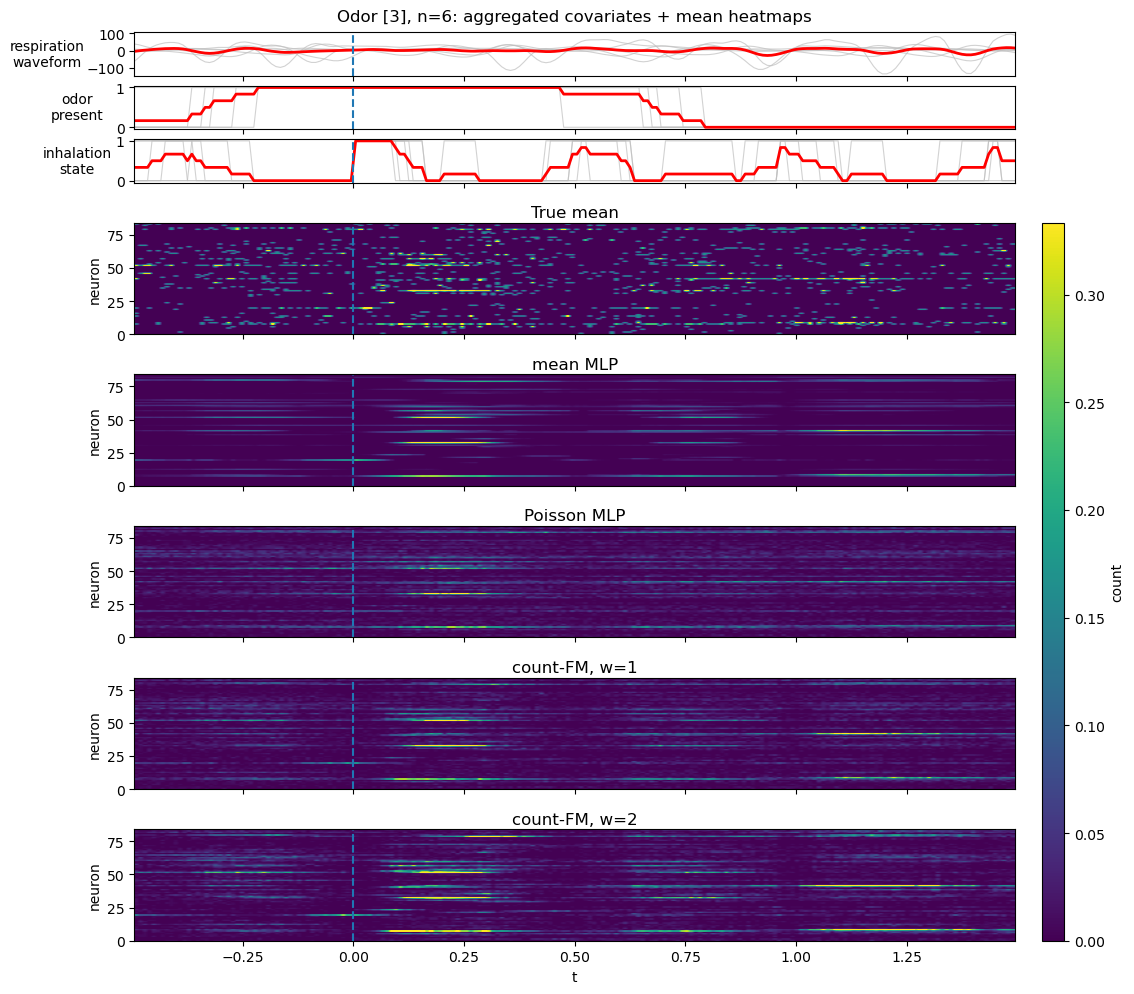

In [10]:
# Figure 1: aggregated covariates + focused-odor mean heatmaps

X_true_mean = _mean_from_record_list(focus_records, "X_real")
X_mean_mean = _mean_from_record_list(focus_records, "X_mean")
X_pois_mean = np.mean(
    np.concatenate([np.asarray(r["X_pois"]) for r in focus_records], axis=0),
    axis=0,
)
X_w1_mean = np.mean(
    np.concatenate([np.asarray(r["X_countfm"][1.0]) for r in focus_records], axis=0),
    axis=0,
)
X_w2_mean = np.mean(
    np.concatenate([np.asarray(r["X_countfm"][2.0]) for r in focus_records], axis=0),
    axis=0,
)

agg_info = _aggregate_covariates_from_records(focus_records)
odor_id_use = agg_info["odor_ids"]
t_ref = agg_info["t"]
xlim = (float(t_ref.min()), float(t_ref.max()))

all_vals = np.concatenate([
    X_true_mean.ravel(),
    X_mean_mean.ravel(),
    X_pois_mean.ravel(),
    X_w1_mean.ravel(),
    X_w2_mean.ravel(),
])
vmin = 0.0
vmax = np.percentile(all_vals, 99.5)

fig = plt.figure(figsize=(12, 11.8))
gs = fig.add_gridspec(
    nrows=6,
    ncols=2,
    width_ratios=[40, 1],
    height_ratios=[1.35, 1, 1, 1, 1, 1],
    hspace=0.34,
    wspace=0.06,
)

_plot_aggregated_covariate_header(
    fig,
    gs[0, 0],
    focus_records,
    title=f"Odor {odor_id_use}, n={agg_info['n_trials']}: aggregated covariates + mean heatmaps",
    xlim=xlim,
)

axes = [fig.add_subplot(gs[i, 0]) for i in range(1, 6)]
cax = fig.add_subplot(gs[1:, 1])

items = [
    ("True mean", X_true_mean),
    ("mean MLP", X_mean_mean),
    ("Poisson MLP", X_pois_mean),
    ("count-FM, w=1", X_w1_mean),
    ("count-FM, w=2", X_w2_mean),
]

for i, (ax, (title, X)) in enumerate(zip(axes, items)):
    im = _plot_trial_heatmap(
        ax,
        X,
        focus_records[0]["C"],
        title=title,
        vmin=vmin,
        vmax=vmax,
        show_xlabel=(i == len(axes) - 1),
        show_ylabel=True,
    )
    ax.set_xlim(xlim)
    ax.margins(x=0)

cb = fig.colorbar(im, cax=cax)
cb.set_label("count")

fig.savefig(FIGDIR / "pcx_figure1_aggregated_heatmaps.pdf", bbox_inches="tight")
plt.show()

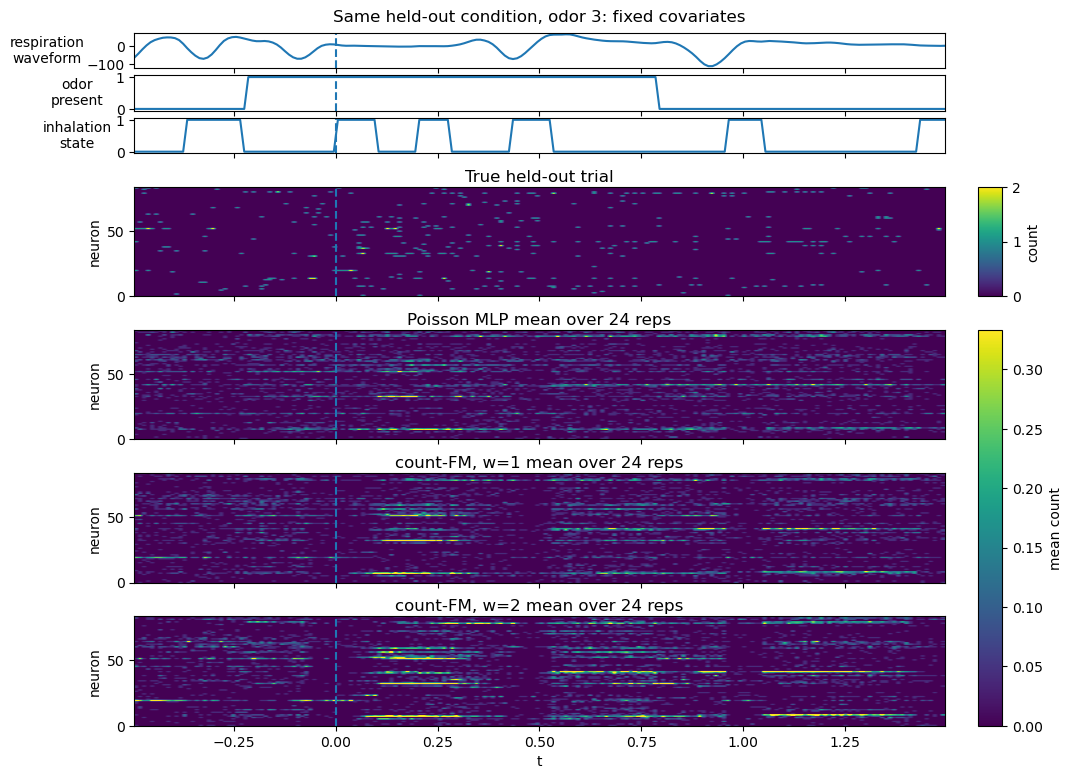

,source,mean_cosine_to_true,sd_cosine_to_true,mean_top10_overlap,sd_top10_overlap,mean_count_ratio_to_true
0,Poisson MLP,0.746706,0.032652,0.336920,0.070627,0.610772
1,count-FM w=1,0.760766,0.033266,0.373016,0.046953,0.657317
2,count-FM w=2,0.794909,0.026751,0.397436,0.054177,0.953659


In [11]:
# Figure 2: one fixed condition, true trial vs generated means, with separate colorbars

example_rec = _pick_representative_focus_record(focus_records)
C_ex = example_rec["C"]

X_true = np.asarray(example_rec["X_real"])
X_pois_mean = np.mean(np.asarray(example_rec["X_pois"]), axis=0)
X_w1_mean = np.mean(np.asarray(example_rec["X_countfm"][1.0]), axis=0)
X_w2_mean = np.mean(np.asarray(example_rec["X_countfm"][2.0]), axis=0)

t_ex = np.asarray(C_ex[:, col_idx["t"]], dtype=float)
xlim = (float(t_ex.min()), float(t_ex.max()))

true_vmin = 0.0
true_vmax = float(np.max(X_true))
true_vmax = max(true_vmax, 1.0)

gen_vals = np.concatenate([
    X_pois_mean.ravel(),
    X_w1_mean.ravel(),
    X_w2_mean.ravel(),
])
gen_vmin = 0.0
gen_vmax = float(np.percentile(gen_vals, 99.5))
gen_vmax = max(gen_vmax, 1e-6)

# fig = plt.figure(figsize=(11.2, 9.0))
# gs = fig.add_gridspec(
#     nrows=5,
#     ncols=3,
#     width_ratios=[40, 1.2, 1.2],
#     height_ratios=[1.1, 1, 1, 1, 1],
#     hspace=0.30,
#     wspace=0.08,
# )

# _plot_single_covariate_header(
#     fig,
#     gs[0, 0],
#     example_rec,
#     title=f"Same held-out condition, odor {example_rec['odor']}: fixed covariates",
#     xlim=xlim,
# )

# ax_off_01 = fig.add_subplot(gs[0, 1]); ax_off_01.axis("off")
# ax_off_02 = fig.add_subplot(gs[0, 2]); ax_off_02.axis("off")

# ax_true = fig.add_subplot(gs[1, 0])
# ax_pois = fig.add_subplot(gs[2, 0])
# ax_w1   = fig.add_subplot(gs[3, 0])
# ax_w2   = fig.add_subplot(gs[4, 0])

# cax_true = fig.add_subplot(gs[1, 1])
# cax_gen  = fig.add_subplot(gs[2:, 2])

# ax_off_11 = fig.add_subplot(gs[1, 2]); ax_off_11.axis("off")
# ax_off_21 = fig.add_subplot(gs[2, 1]); ax_off_21.axis("off")
# ax_off_31 = fig.add_subplot(gs[3, 1]); ax_off_31.axis("off")
# ax_off_41 = fig.add_subplot(gs[4, 1]); ax_off_41.axis("off")

fig = plt.figure(figsize=(11.2, 9.0))
gs = fig.add_gridspec(
    nrows=5,
    ncols=2,
    width_ratios=[40, 1.2],
    height_ratios=[1.1, 1, 1, 1, 1],
    hspace=0.30,
    wspace=0.08,
)

_plot_single_covariate_header(
    fig,
    gs[0, 0],
    example_rec,
    title=f"Same held-out condition, odor {example_rec['odor']}: fixed covariates",
    xlim=xlim,
)

ax_off_01 = fig.add_subplot(gs[0, 1])
ax_off_01.axis("off")

ax_true = fig.add_subplot(gs[1, 0])
ax_pois = fig.add_subplot(gs[2, 0])
ax_w1   = fig.add_subplot(gs[3, 0])
ax_w2   = fig.add_subplot(gs[4, 0])

cax_true = fig.add_subplot(gs[1, 1])
cax_gen  = fig.add_subplot(gs[2:, 1])


im_true = _plot_trial_heatmap(
    ax_true,
    X_true,
    C_ex,
    title="True held-out trial",
    vmin=true_vmin,
    vmax=true_vmax,
    show_xlabel=False,
    show_ylabel=True,
)
ax_true.set_xlim(xlim)
ax_true.margins(x=0)

cb_true = fig.colorbar(im_true, cax=cax_true)
cb_true.set_label("count")
if true_vmax <= 8:
    cb_true.set_ticks(np.arange(0, int(true_vmax) + 1, 1))

im_pois = _plot_trial_heatmap(
    ax_pois,
    X_pois_mean,
    C_ex,
    title=f"Poisson MLP mean over {len(example_rec['X_pois'])} reps",
    vmin=gen_vmin,
    vmax=gen_vmax,
    show_xlabel=False,
    show_ylabel=True,
)
ax_pois.set_xlim(xlim)
ax_pois.margins(x=0)

im_w1 = _plot_trial_heatmap(
    ax_w1,
    X_w1_mean,
    C_ex,
    title=f"count-FM, w=1 mean over {len(example_rec['X_countfm'][1.0])} reps",
    vmin=gen_vmin,
    vmax=gen_vmax,
    show_xlabel=False,
    show_ylabel=True,
)
ax_w1.set_xlim(xlim)
ax_w1.margins(x=0)

im_w2 = _plot_trial_heatmap(
    ax_w2,
    X_w2_mean,
    C_ex,
    title=f"count-FM, w=2 mean over {len(example_rec['X_countfm'][2.0])} reps",
    vmin=gen_vmin,
    vmax=gen_vmax,
    show_xlabel=True,
    show_ylabel=True,
)
ax_w2.set_xlim(xlim)
ax_w2.margins(x=0)

# cb_gen = fig.colorbar(im_w2, cax=cax_gen)
# cb_gen.set_label("mean count")

# plt.show()

cb_gen = fig.colorbar(im_w2, cax=cax_gen)
cb_gen.set_label("mean count")

fig.savefig(FIGDIR / "pcx_figure2_fixed_condition.pdf", bbox_inches="tight")
plt.show()


# quick quantitative support for this one fixed-condition figure
def summarize_replicate_bank(X_bank, C_raw):
    V = np.stack([trial_response_vector(x, C_raw) for x in X_bank], axis=0)
    return V

V_pois = summarize_replicate_bank(np.asarray(example_rec["X_pois"]), C_ex)
V_w1 = summarize_replicate_bank(np.asarray(example_rec["X_countfm"][1.0]), C_ex)
V_w2 = summarize_replicate_bank(np.asarray(example_rec["X_countfm"][2.0]), C_ex)
v_true = trial_response_vector(X_true, C_ex)

def mean_cos_to_true(V, v_true):
    vals = [cosine_sim(v, v_true) for v in V]
    return float(np.mean(vals)), float(np.std(vals))

def mean_topk_to_true(V, v_true, k=10):
    vals = [topk_overlap(v, v_true, k=k) for v in V]
    return float(np.mean(vals)), float(np.std(vals))

rows = []
for label, V in [
    ("Poisson MLP", V_pois),
    ("count-FM w=1", V_w1),
    ("count-FM w=2", V_w2),
]:
    cos_mu, cos_sd = mean_cos_to_true(V, v_true)
    topk_mu, topk_sd = mean_topk_to_true(V, v_true, k=TOPK)
    cnt_ratio = float(np.mean(V.sum(axis=1) / max(v_true.sum(), 1e-8)))
    rows.append({
        "source": label,
        "mean_cosine_to_true": cos_mu,
        "sd_cosine_to_true": cos_sd,
        "mean_top10_overlap": topk_mu,
        "sd_top10_overlap": topk_sd,
        "mean_count_ratio_to_true": cnt_ratio,
    })

replicate_support_df = pd.DataFrame(rows)
display(replicate_support_df)

In [12]:
# Table 1: compact global benchmark

real_vecs, real_odors, real_totals = get_trial_vectors(global_records, "real")
real_mean_map = per_odor_mean_maps(real_vecs, real_odors)
real_corr = residual_corr(real_vecs, real_odors)

metric_rows = []
for source in ["mean", "pois"] + [float(w) for w in GLOBAL_GUIDE_SCALES]:
    vecs, odors, totals = get_trial_vectors(global_records, source)
    mean_map = per_odor_mean_maps(vecs, odors)
    corr = residual_corr(vecs, odors)

    metric_rows.append({
        "source": source,
        "mean_rmse": map_rmse(real_mean_map, mean_map),
        "corr_rmse": corr_offdiag_rmse(real_corr, corr),
        "tail95_error": tail_exceedance_error(real_totals, real_odors, totals, odors, q=0.95),
    })

metrics_df = pd.DataFrame(metric_rows)

cmp_df = build_condition_matched_df(
    global_records,
    sources=("mean", "pois", 0.0, 0.5, 1.0, 1.5, 2.0),
    topk=TOPK,
)

matched_summary = (
    cmp_df.groupby("source")[["cosine_to_matched", "topk_overlap", "count_ratio"]]
    .mean()
    .reset_index()
)

def normalize_source_label(x):
    if x == "mean":
        return "Mean MLP"
    if x == "pois":
        return "Poisson MLP"
    if isinstance(x, str) and x.startswith("count-FM"):
        return x
    return f"count-FM w={float(x):.1f}"

metrics_df["source"] = metrics_df["source"].map(normalize_source_label)

table1_df = metrics_df.merge(matched_summary, on="source", how="left")
table1_df = table1_df[
    ["source", "mean_rmse", "corr_rmse", "tail95_error", "cosine_to_matched", "topk_overlap", "count_ratio"]
].copy()

source_order = [
    "Mean MLP",
    "Poisson MLP",
    "count-FM w=0.0",
    "count-FM w=0.5",
    "count-FM w=1.0",
    "count-FM w=1.5",
    "count-FM w=2.0",
]
table1_df["source"] = pd.Categorical(table1_df["source"], categories=source_order, ordered=True)
table1_df = table1_df.sort_values("source").reset_index(drop=True)

display(table1_df)

,source,mean_rmse,corr_rmse,tail95_error,cosine_to_matched,topk_overlap,count_ratio
0,Mean MLP,1.074923,0.293502,0.500000,0.816423,0.517355,0.760749
1,Poisson MLP,1.082222,0.262984,0.276042,0.724328,0.392481,1.164751
2,count-FM w=0.0,1.290330,0.262529,0.296875,0.652313,0.334842,1.017856
3,count-FM w=0.5,1.012501,0.263062,0.286458,0.734347,0.378310,1.035618
4,count-FM w=1.0,0.973573,0.256200,0.260417,0.768483,0.430004,1.110348
5,count-FM w=1.5,1.135103,0.256549,0.255208,0.774273,0.451387,1.284288
6,count-FM w=2.0,1.378912,0.260009,0.375000,0.775259,0.451137,1.448973


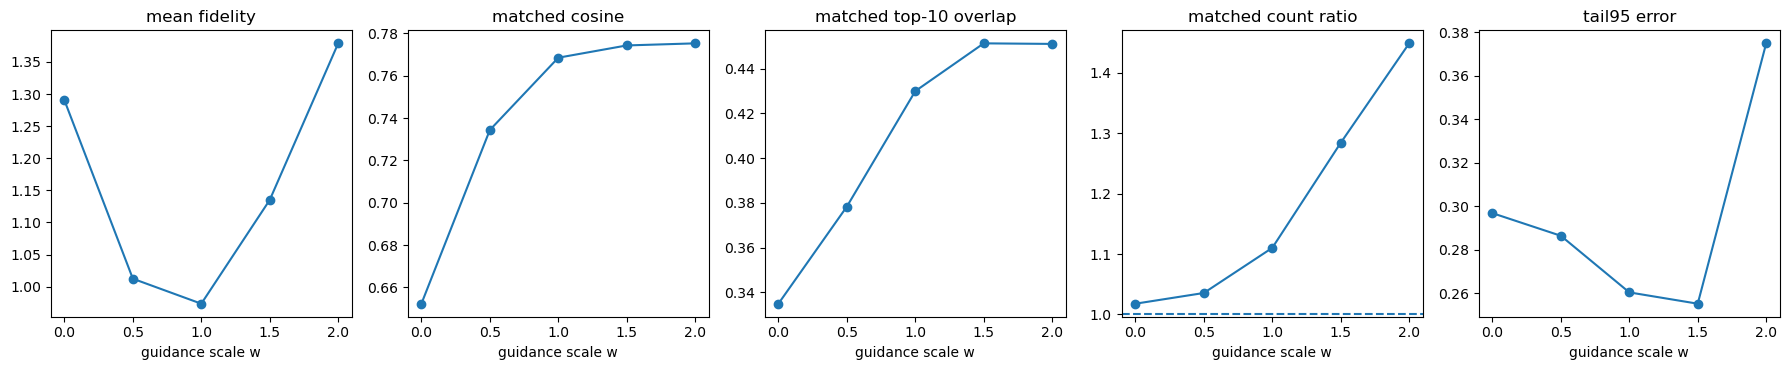

In [13]:
# Figure 3: guidance decomposition, shape vs amplitude / calibration

guide_df = table1_df[table1_df["source"].astype(str).str.startswith("count-FM")].copy()
guide_df["w"] = guide_df["source"].astype(str).str.replace("count-FM w=", "", regex=False).astype(float)
guide_df = guide_df.sort_values("w").reset_index(drop=True)

fig, axes = plt.subplots(1, 5, figsize=(18, 3.8))

axes[0].plot(guide_df["w"], guide_df["mean_rmse"], marker="o")
axes[0].set_title("mean fidelity")
axes[0].set_xlabel("guidance scale w")

axes[1].plot(guide_df["w"], guide_df["cosine_to_matched"], marker="o")
axes[1].set_title("matched cosine")
axes[1].set_xlabel("guidance scale w")

axes[2].plot(guide_df["w"], guide_df["topk_overlap"], marker="o")
axes[2].set_title(f"matched top-{TOPK} overlap")
axes[2].set_xlabel("guidance scale w")

axes[3].plot(guide_df["w"], guide_df["count_ratio"], marker="o")
axes[3].axhline(1.0, ls="--")
axes[3].set_title("matched count ratio")
axes[3].set_xlabel("guidance scale w")

axes[4].plot(guide_df["w"], guide_df["tail95_error"], marker="o")
axes[4].set_title("tail95 error")
axes[4].set_xlabel("guidance scale w")

# plt.tight_layout()
# plt.show()

plt.tight_layout()
fig.savefig(FIGDIR / "pcx_figure3_guidance_decomposition.pdf", bbox_inches="tight")
plt.show()

In [14]:
# concise summary objects to keep for writing / export

paper_outputs = {
    "Figure 1": "Aggregated covariates + focused-odor mean heatmaps",
    "Figure 2": "Fixed-condition true trial vs generated mean responses, with separate true / generated colorbars",
    "Table 1": "Global benchmark with fidelity, calibration, and matched-shape metrics",
    "Figure 3": "Guidance decomposition over w: shape alignment vs amplitude / tail calibration",
}

summary_notes = {
    "main_story_1": "Nonlinear mean MLP is too smooth; nonlinear Poisson MLP is a strong count baseline but remains more diffuse than count-FM.",
    "main_story_2": "count-FM recovers structured covariate-locked response patterns and improves global conditional fidelity over regression baselines.",
    "main_story_3": "Increasing guidance changes shape alignment and amplitude / tail behavior differently, so w is a tradeoff rather than a monotone calibration knob.",
}

display(pd.DataFrame({"artifact": list(paper_outputs.keys()), "description": list(paper_outputs.values())}))
display(pd.DataFrame({"note": list(summary_notes.keys()), "text": list(summary_notes.values())}))

,artifact,description
0,Figure 1,Aggregated covariates + focused-odor mean heat...
1,Figure 2,Fixed-condition true trial vs generated mean r...
2,Table 1,"Global benchmark with fidelity, calibration, a..."
3,Figure 3,Guidance decomposition over w: shape alignment...


,note,text
0,main_story_1,Nonlinear mean MLP is too smooth; nonlinear Po...
1,main_story_2,count-FM recovers structured covariate-locked ...
2,main_story_3,Increasing guidance changes shape alignment an...


In [15]:
# Appendix support bank on ALL held-out trials
# This is separate from global_records, which is only a subset.

APP_GUIDE_SCALES = [0.0, 1.0, 2.0]
APP_REPS = GLOBAL_REPS
APP_STEPS = GLOBAL_STEPS

if "all_val_records" not in globals():
    all_val_local_idx = np.arange(len(Xva_list), dtype=np.int64)
    all_val_records = build_bank(
        local_idx_array=all_val_local_idx,
        guide_scales=APP_GUIDE_SCALES,
        n_rep=APP_REPS,
        n_step=APP_STEPS,
    )

print("all held-out trials:", len(all_val_records))

all held-out trials: 96


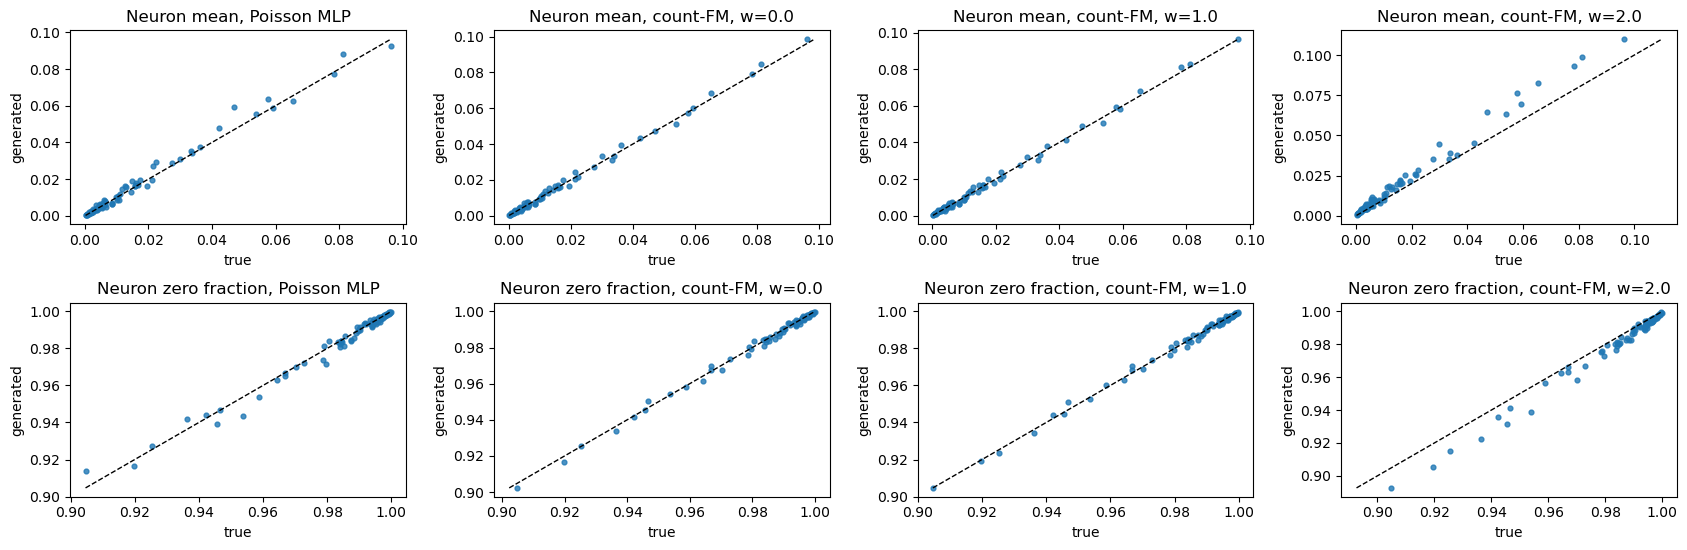

In [16]:
# Appendix Figure A1: neuron-wise marginal diagnostics, now with Poisson baseline

def _stack_timebins(records, source):
    mats = []
    for rec in records:
        if source == "real":
            xs = [rec["X_real"]]
        elif source == "pois":
            xs = list(rec["X_pois"])
        else:
            xs = list(rec["X_countfm"][float(source)])

        for x in xs:
            mats.append(np.asarray(x, dtype=np.float32))
    return np.concatenate(mats, axis=0)  # [all_timebins, neuron]

def _neuron_stats(X):
    mu = X.mean(axis=0)
    zf = (X == 0).mean(axis=0)
    return mu, zf

X_true_all = _stack_timebins(all_val_records, "real")
true_mean, true_zero = _neuron_stats(X_true_all)

scatter_sources = [
    ("Poisson MLP", "pois"),
    ("count-FM, w=0.0", 0.0),
    ("count-FM, w=1.0", 1.0),
    ("count-FM, w=2.0", 2.0),
]

fig, axes = plt.subplots(2, len(scatter_sources), figsize=(17.0, 5.6))

for j, (title, source) in enumerate(scatter_sources):
    X_gen_all = _stack_timebins(all_val_records, source)
    gen_mean, gen_zero = _neuron_stats(X_gen_all)

    ax = axes[0, j]
    ax.scatter(true_mean, gen_mean, s=12, alpha=0.8)
    lo = min(true_mean.min(), gen_mean.min())
    hi = max(true_mean.max(), gen_mean.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_title(f"Neuron mean, {title}", fontsize=12)
    ax.set_xlabel("true")
    ax.set_ylabel("generated")

    ax = axes[1, j]
    ax.scatter(true_zero, gen_zero, s=12, alpha=0.8)
    lo = min(true_zero.min(), gen_zero.min())
    hi = max(true_zero.max(), gen_zero.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_title(f"Neuron zero fraction, {title}", fontsize=12)
    ax.set_xlabel("true")
    ax.set_ylabel("generated")

plt.tight_layout()
fig.savefig(FIGDIR / "pcx_appendix_neuron_marginal_scatter_with_poisson.pdf", bbox_inches="tight")
plt.show()

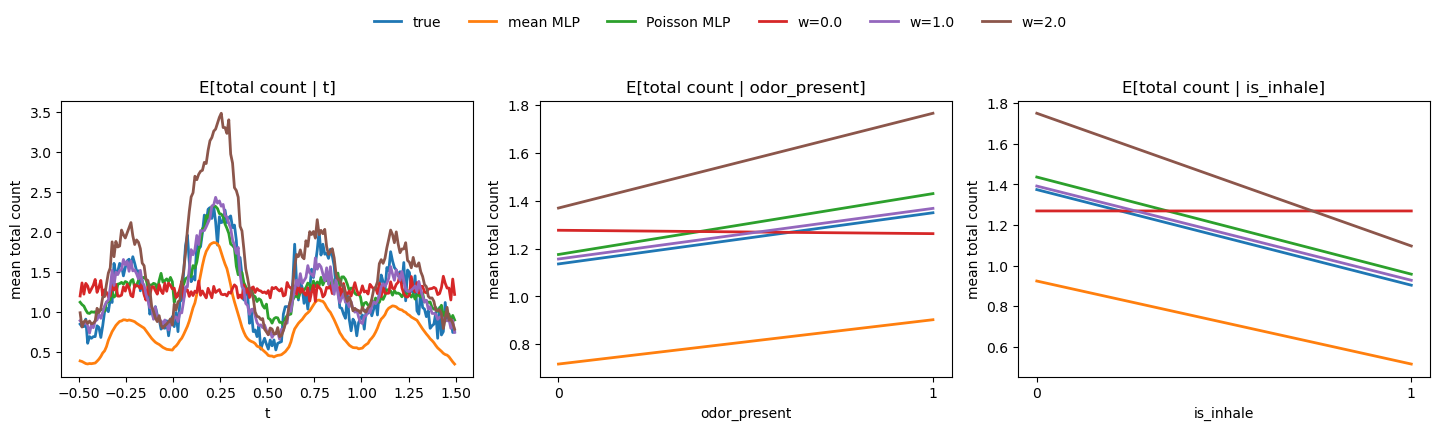

In [17]:
# Appendix Figure A2: conditional calibration, now with BOTH baselines

def _total_count_long_df(records, source):
    chunks = []

    for rec in records:
        C = np.asarray(rec["C"], dtype=np.float32)

        if source == "real":
            xs = [rec["X_real"]]
            label = "true"
        elif source == "mean":
            xs = [rec["X_mean"]]
            label = "mean MLP"
        elif source == "pois":
            xs = list(rec["X_pois"])
            label = "Poisson MLP"
        else:
            xs = list(rec["X_countfm"][float(source)])
            label = f"w={float(source):.1f}"

        base_df = pd.DataFrame({
            "t": C[:, col_idx["t"]].astype(np.float32),
            "odor_present": np.rint(C[:, col_idx["odor_present"]]).astype(np.int64),
            "is_inhale": np.rint(C[:, col_idx["is_inhale"]]).astype(np.int64),
        })

        for x in xs:
            tmp = base_df.copy()
            tmp["total_count"] = np.asarray(x, dtype=np.float32).sum(axis=1)
            tmp["source"] = label
            chunks.append(tmp)

    return pd.concat(chunks, axis=0, ignore_index=True)

cal_sources = ["real", "mean", "pois", 0.0, 1.0, 2.0]
cal_df = pd.concat(
    [_total_count_long_df(all_val_records, s) for s in cal_sources],
    axis=0,
    ignore_index=True,
)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))

for label, sub in cal_df.groupby("source", sort=False):
    g_t = sub.groupby("t", as_index=False)["total_count"].mean().sort_values("t")
    axes[0].plot(g_t["t"], g_t["total_count"], lw=2, label=label)

    g_o = sub.groupby("odor_present", as_index=False)["total_count"].mean().sort_values("odor_present")
    axes[1].plot(g_o["odor_present"], g_o["total_count"], lw=2, label=label)

    g_i = sub.groupby("is_inhale", as_index=False)["total_count"].mean().sort_values("is_inhale")
    axes[2].plot(g_i["is_inhale"], g_i["total_count"], lw=2, label=label)

axes[0].set_title("E[total count | t]")
axes[0].set_xlabel("t")
axes[0].set_ylabel("mean total count")

axes[1].set_title("E[total count | odor_present]")
axes[1].set_xlabel("odor_present")
axes[1].set_ylabel("mean total count")
axes[1].set_xticks([0, 1])

axes[2].set_title("E[total count | is_inhale]")
axes[2].set_xlabel("is_inhale")
axes[2].set_ylabel("mean total count")
axes[2].set_xticks([0, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=6,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.88])
fig.savefig(FIGDIR / "pcx_appendix_conditional_calibration_with_baselines.pdf", bbox_inches="tight")
plt.show()

# Replication

In [36]:
# Replication Cell 1
# fresh, honest multi-run replication for Table 3

from pathlib import Path
import random
import copy

PCX_REP_DIR_FRESH = Path("pcx_replication_fresh_v2")
PCX_REP_DIR_FRESH.mkdir(parents=True, exist_ok=True)

OUTER_SEEDS = [0, 1, 2, 3, 4]
TRAIN_IF_MISSING = False   # first run: True. after checkpoints exist, change to False.

# slightly safer / less noisy than the quick exploratory setup
REPL_BASE_NUM_EPOCHS = max(BASE_NUM_EPOCHS, 80)
REPL_COUNTFM_NUM_EPOCHS = max(COUNTFM_NUM_EPOCHS, 80)
REPL_GLOBAL_REPS = max(GLOBAL_REPS, 12)
REPL_GLOBAL_STEPS = max(GLOBAL_STEPS, 100)
REPL_GLOBAL_MAX_TRIALS_PER_ODOR = GLOBAL_MAX_TRIALS_PER_ODOR

PCX_MODEL_ORDER = [
    "MLP mean",
    "Poisson MLP",
    "count-FM, w=0",
    "count-FM, w=1",
    "count-FM, w=2",
]

def set_all_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def repl_ckpt_path(seed):
    return PCX_REP_DIR_FRESH / f"pcx_repl_seed{seed}_base{REPL_BASE_NUM_EPOCHS}_fm{REPL_COUNTFM_NUM_EPOCHS}.pt"

def flatten_pcx_summary(summary_df):
    rows = []
    for model in PCX_MODEL_ORDER:
        rows.append({
            "Model": model,
            "Mean RMSE": f"{summary_df.loc[model, ('mean_rmse', 'mean')]:.3f} ± {summary_df.loc[model, ('mean_rmse', 'std')]:.3f}",
            "Matched cosine": f"{summary_df.loc[model, ('cosine_to_matched', 'mean')]:.3f} ± {summary_df.loc[model, ('cosine_to_matched', 'std')]:.3f}",
            "Mean-count ratio": f"{summary_df.loc[model, ('count_ratio', 'mean')]:.3f} ± {summary_df.loc[model, ('count_ratio', 'std')]:.3f}",
            "95th-percentile error": f"{summary_df.loc[model, ('tail95_error', 'mean')]:.3f} ± {summary_df.loc[model, ('tail95_error', 'std')]:.3f}",
        })
    return pd.DataFrame(rows)

def build_trial_split_and_features_repl(seed):
    tr_trials_seed, va_trials_seed = stratified_trial_split(trial_odor_ids, p_train=0.8, seed=seed)

    Xtr_list_seed = [np.clip(np.asarray(X_list[i]), 0, None).astype(np.int64) for i in tr_trials_seed]
    Xva_list_seed = [np.clip(np.asarray(X_list[i]), 0, None).astype(np.int64) for i in va_trials_seed]

    Ctr_raw_list_seed = [np.asarray(C_list[i], dtype=np.float32) for i in tr_trials_seed]
    Cva_raw_list_seed = [np.asarray(C_list[i], dtype=np.float32) for i in va_trials_seed]

    Xtr_seed = np.concatenate(Xtr_list_seed, axis=0)
    Xva_seed = np.concatenate(Xva_list_seed, axis=0)
    Ctr_raw_seed = np.concatenate(Ctr_raw_list_seed, axis=0)
    Cva_raw_seed = np.concatenate(Cva_raw_list_seed, axis=0)

    mask_tr_seed = np.isfinite(Xtr_seed).all(axis=1) & np.isfinite(Ctr_raw_seed).all(axis=1)
    mask_va_seed = np.isfinite(Xva_seed).all(axis=1) & np.isfinite(Cva_raw_seed).all(axis=1)

    Xtr_seed = Xtr_seed[mask_tr_seed]
    Xva_seed = Xva_seed[mask_va_seed]
    Ctr_raw_seed = Ctr_raw_seed[mask_tr_seed]
    Cva_raw_seed = Cva_raw_seed[mask_va_seed]

    Ctr_cont_seed = Ctr_raw_seed[:, cont_idx].astype(np.float32) if len(cont_idx) > 0 else np.zeros((Ctr_raw_seed.shape[0], 0), dtype=np.float32)
    Cva_cont_seed = Cva_raw_seed[:, cont_idx].astype(np.float32) if len(cont_idx) > 0 else np.zeros((Cva_raw_seed.shape[0], 0), dtype=np.float32)

    Ctr_cat_seed = np.rint(Ctr_raw_seed[:, cat_idx]).astype(np.int64) if len(cat_idx) > 0 else np.zeros((Ctr_raw_seed.shape[0], 0), dtype=np.int64)
    Cva_cat_seed = np.rint(Cva_raw_seed[:, cat_idx]).astype(np.int64) if len(cat_idx) > 0 else np.zeros((Cva_raw_seed.shape[0], 0), dtype=np.int64)

    feature_enc_seed = fit_feature_encoder(Ctr_cont_seed, Ctr_cat_seed, cat_cardinalities)
    Phi_tr_seed = transform_features(Ctr_cont_seed, Ctr_cat_seed, feature_enc_seed)
    Phi_va_seed = transform_features(Cva_cont_seed, Cva_cat_seed, feature_enc_seed)

    return {
        "tr_trials": tr_trials_seed,
        "va_trials": va_trials_seed,
        "Xtr_list": Xtr_list_seed,
        "Xva_list": Xva_list_seed,
        "Ctr_raw_list": Ctr_raw_list_seed,
        "Cva_raw_list": Cva_raw_list_seed,
        "Xtr": Xtr_seed,
        "Xva": Xva_seed,
        "Ctr_cont": Ctr_cont_seed,
        "Cva_cont": Cva_cont_seed,
        "Ctr_cat": Ctr_cat_seed,
        "Cva_cat": Cva_cat_seed,
        "Phi_tr": Phi_tr_seed,
        "Phi_va": Phi_va_seed,
        "feature_enc": feature_enc_seed,
        "x0_rate": float(Xtr_seed.mean()),
        "d_neuron": int(Xtr_seed.shape[1]),
    }

def init_models_repl(split_obj):
    mean_model_seed = MeanMLP(
        in_dim=split_obj["Phi_tr"].shape[1],
        out_dim=split_obj["d_neuron"],
        hidden=128,
        depth=3,
    )
    pois_model_seed = PoissonMLP(
        in_dim=split_obj["Phi_tr"].shape[1],
        out_dim=split_obj["d_neuron"],
        hidden=128,
        depth=3,
    )
    countfm_model_seed = CondCountFMNet_MLP(
        d=split_obj["d_neuron"],
        cont_dim=split_obj["Ctr_cont"].shape[1],
        cat_cardinalities=cat_cardinalities,
        emb_dim=16,
        hidden=128,
        depth=3,
        log_cap=5.0,
        eps_time=COUNTFM_EPS_T,
    )
    return mean_model_seed, pois_model_seed, countfm_model_seed

def train_or_load_models_repl(seed, split_obj):
    set_all_seeds(seed)

    ckpt = repl_ckpt_path(seed)
    mean_model_seed, pois_model_seed, countfm_model_seed = init_models_repl(split_obj)

    if ckpt.exists():
        blob = torch.load(ckpt, map_location="cpu")
        mean_model_seed.load_state_dict(blob["mean_state"])
        pois_model_seed.load_state_dict(blob["pois_state"])
        countfm_model_seed.load_state_dict(blob["countfm_state"])
        x0_rate_seed = float(blob["x0_rate"])
    else:
        if not TRAIN_IF_MISSING:
            raise FileNotFoundError(f"Missing checkpoint: {ckpt}")

        Phi_tr_t_seed = torch.from_numpy(split_obj["Phi_tr"]).float()
        Phi_va_t_seed = torch.from_numpy(split_obj["Phi_va"]).float()
        Xtr_t_seed = torch.from_numpy(split_obj["Xtr"]).float()
        Xva_t_seed = torch.from_numpy(split_obj["Xva"]).float()
        Ctr_cont_t_seed = torch.from_numpy(split_obj["Ctr_cont"]).float()
        Cva_cont_t_seed = torch.from_numpy(split_obj["Cva_cont"]).float()
        Ctr_cat_t_seed = torch.from_numpy(split_obj["Ctr_cat"]).long()
        Cva_cat_t_seed = torch.from_numpy(split_obj["Cva_cat"]).long()

        base_train_ds_seed = TensorDataset(Phi_tr_t_seed, Xtr_t_seed)
        base_val_ds_seed = TensorDataset(Phi_va_t_seed, Xva_t_seed)
        base_train_loader_seed = DataLoader(base_train_ds_seed, batch_size=BASE_BATCH_SIZE, shuffle=True, drop_last=True)
        base_val_loader_seed = DataLoader(base_val_ds_seed, batch_size=BASE_BATCH_SIZE, shuffle=False, drop_last=False)

        mean_model_seed = train_supervised(
            mean_model_seed,
            base_train_loader_seed,
            base_val_loader_seed,
            loss_fn=nn.MSELoss(),
            lr=BASE_LR,
            weight_decay=BASE_WEIGHT_DECAY,
            num_epochs=REPL_BASE_NUM_EPOCHS,
        )

        pois_loss_fn_seed = lambda pred, target: F.poisson_nll_loss(pred, target, log_input=False, full=True)
        pois_model_seed = train_supervised(
            pois_model_seed,
            base_train_loader_seed,
            base_val_loader_seed,
            loss_fn=pois_loss_fn_seed,
            lr=BASE_LR,
            weight_decay=BASE_WEIGHT_DECAY,
            num_epochs=REPL_BASE_NUM_EPOCHS,
        )

        x0_rate_seed = float(split_obj["x0_rate"])
        countfm_model_seed = train_countfm(
            countfm_model_seed,
            Xtr_t_seed, Ctr_cont_t_seed, Ctr_cat_t_seed,
            Xva_t_seed, Cva_cont_t_seed, Cva_cat_t_seed,
            x0_poisson_rate=x0_rate_seed,
            batch_size=COUNTFM_BATCH_SIZE,
            lr=COUNTFM_LR,
            weight_decay=COUNTFM_WEIGHT_DECAY,
            num_epochs=REPL_COUNTFM_NUM_EPOCHS,
            p_uncond=COUNTFM_P_UNCOND,
            eps_t=COUNTFM_EPS_T,
        )

        torch.save(
            {
                "mean_state": mean_model_seed.state_dict(),
                "pois_state": pois_model_seed.state_dict(),
                "countfm_state": countfm_model_seed.state_dict(),
                "x0_rate": x0_rate_seed,
                "seed": seed,
                "base_epochs": REPL_BASE_NUM_EPOCHS,
                "countfm_epochs": REPL_COUNTFM_NUM_EPOCHS,
            },
            ckpt,
        )

    return (
        mean_model_seed.to(device).eval(),
        pois_model_seed.to(device).eval(),
        countfm_model_seed.to(device).eval(),
        x0_rate_seed,
    )

def split_trial_covariates_repl(C_trial):
    C_trial = np.asarray(C_trial, dtype=np.float32)
    c_cont = C_trial[:, cont_idx].astype(np.float32) if len(cont_idx) > 0 else np.zeros((C_trial.shape[0], 0), dtype=np.float32)
    c_cat = np.rint(C_trial[:, cat_idx]).astype(np.int64) if len(cat_idx) > 0 else np.zeros((C_trial.shape[0], 0), dtype=np.int64)
    return c_cont, c_cat

def make_local_trial_samplers_repl(mean_model_seed, pois_model_seed, countfm_model_seed, feature_enc_seed, d_neuron_seed, x0_rate_seed):
    def baseline_mean_trial_local(C_trial):
        c_cont, c_cat = split_trial_covariates_repl(C_trial)
        Phi = transform_features(c_cont, c_cat, feature_enc_seed)
        with torch.no_grad():
            x = torch.from_numpy(Phi).float().to(device)
            y = mean_model_seed(x).cpu().numpy()
        return y.astype(np.float32)

    def baseline_pois_trial_local(C_trial, n_rep):
        c_cont, c_cat = split_trial_covariates_repl(C_trial)
        Phi = transform_features(c_cont, c_cat, feature_enc_seed)
        with torch.no_grad():
            x = torch.from_numpy(Phi).float().to(device)
            lam = pois_model_seed(x).cpu().numpy()
        out = np.random.poisson(np.clip(lam, 1e-8, None), size=(n_rep,) + lam.shape)
        return out.astype(np.int64)

    @torch.no_grad()
    def sample_countfm_trial_local(C_trial, n_rep, guidance_scale, n_step):
        c_cont_np, c_cat_np = split_trial_covariates_repl(C_trial)
        T_local = c_cont_np.shape[0]

        c_cont = torch.from_numpy(c_cont_np).float().to(device).repeat((n_rep, 1))
        c_cat = torch.from_numpy(c_cat_np).long().to(device).repeat((n_rep, 1))

        xt = torch.poisson(
            torch.full((n_rep * T_local, d_neuron_seed), float(x0_rate_seed), device=device, dtype=torch.float32)
        )
        xt = sample_euler_cfg_condcountfm(
            countfm_model_seed, n_step, xt, c_cont, c_cat,
            guidance_scale=guidance_scale, eps_t=COUNTFM_EPS_T,
        )

        return xt.cpu().numpy().astype(np.int64).reshape(n_rep, T_local, d_neuron_seed)


    return baseline_mean_trial_local, baseline_pois_trial_local, sample_countfm_trial_local

def build_global_records_repl(split_obj, baseline_mean_fn, baseline_pois_fn, sample_countfm_fn, subset_seed):
    val_trial_odor_ids = trial_odor_ids[split_obj["va_trials"]]
    rng = np.random.default_rng(subset_seed)

    global_local_idx = []
    for odor in np.unique(val_trial_odor_ids):
        idx = np.where(val_trial_odor_ids == odor)[0]
        if len(idx) <= REPL_GLOBAL_MAX_TRIALS_PER_ODOR:
            picked = idx
        else:
            picked = np.sort(rng.choice(idx, size=REPL_GLOBAL_MAX_TRIALS_PER_ODOR, replace=False))
        global_local_idx.extend(picked.tolist())
    global_local_idx = np.array(sorted(global_local_idx), dtype=np.int64)

    out = []
    for local_i in global_local_idx:
        X_real = np.asarray(split_obj["Xva_list"][local_i]).astype(np.int64)
        C_trial = np.asarray(split_obj["Cva_raw_list"][local_i]).astype(np.float32)
        odor_i = int(np.rint(C_trial[0, col_idx["odor_id"]]))

        rec = {
            "local_i": int(local_i),
            "odor": odor_i,
            "C": C_trial,
            "X_real": X_real,
            "X_mean": baseline_mean_fn(C_trial),
            "X_pois": baseline_pois_fn(C_trial, REPL_GLOBAL_REPS),
            "X_countfm": {
                0.0: sample_countfm_fn(C_trial, REPL_GLOBAL_REPS, 0.0, REPL_GLOBAL_STEPS),
                1.0: sample_countfm_fn(C_trial, REPL_GLOBAL_REPS, 1.0, REPL_GLOBAL_STEPS),
                2.0: sample_countfm_fn(C_trial, REPL_GLOBAL_REPS, 2.0, REPL_GLOBAL_STEPS),
            },
        }
        out.append(rec)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return out

def evaluate_records_repl(records):
    real_vecs, real_odors, real_totals = get_trial_vectors(records, "real")
    real_mean_map = per_odor_mean_maps(real_vecs, real_odors)

    metric_rows = []
    for source in ["mean", "pois", 0.0, 1.0, 2.0]:
        vecs, odors, totals = get_trial_vectors(records, source)
        mean_map = per_odor_mean_maps(vecs, odors)

        if source == "mean":
            model_name = "MLP mean"
        elif source == "pois":
            model_name = "Poisson MLP"
        else:
            model_name = f"count-FM, w={int(source)}"

        metric_rows.append({
            "Model": model_name,
            "mean_rmse": map_rmse(real_mean_map, mean_map),
            "tail95_error": tail_exceedance_error(real_totals, real_odors, totals, odors, q=0.95),
        })

    metrics_df = pd.DataFrame(metric_rows)

    cmp_rows = []
    for rec in records:
        v_true = trial_response_vector(rec["X_real"], rec["C"])
        s_true = float(v_true.sum())

        cmp_rows.append({
            "Model": "MLP mean",
            "cosine_to_matched": cosine_sim(trial_response_vector(rec["X_mean"], rec["C"]), v_true),
            "count_ratio": float(trial_response_vector(rec["X_mean"], rec["C"]).sum()) / max(s_true, 1e-8),
        })

        for x in rec["X_pois"]:
            v = trial_response_vector(x, rec["C"])
            cmp_rows.append({
                "Model": "Poisson MLP",
                "cosine_to_matched": cosine_sim(v, v_true),
                "count_ratio": float(v.sum()) / max(s_true, 1e-8),
            })

        for w in [0.0, 1.0, 2.0]:
            for x in rec["X_countfm"][w]:
                v = trial_response_vector(x, rec["C"])
                cmp_rows.append({
                    "Model": f"count-FM, w={int(w)}",
                    "cosine_to_matched": cosine_sim(v, v_true),
                    "count_ratio": float(v.sum()) / max(s_true, 1e-8),
                })

    cmp_df = pd.DataFrame(cmp_rows)
    cmp_summary = cmp_df.groupby("Model")[["cosine_to_matched", "count_ratio"]].mean().reset_index()

    table_df = metrics_df.merge(cmp_summary, on="Model", how="left")
    table_df["Model"] = pd.Categorical(table_df["Model"], categories=PCX_MODEL_ORDER, ordered=True)
    table_df = table_df.sort_values("Model").reset_index(drop=True)
    return table_df

In [37]:
# Replication Cell 2
# one-time training / loading

if TRAIN_IF_MISSING:
    for outer_seed in OUTER_SEEDS:
        print(f"\n===== outer seed {outer_seed} =====")
        split_obj_seed = build_trial_split_and_features_repl(outer_seed)
        _ = train_or_load_models_repl(outer_seed, split_obj_seed)

In [38]:
# Replication Cell 3
# final replicated Table 3

outer_rows = []

for outer_seed in OUTER_SEEDS:
    print(f"running outer seed {outer_seed}")

    split_obj_seed = build_trial_split_and_features_repl(outer_seed)
    mean_model_seed, pois_model_seed, countfm_model_seed, x0_rate_seed = train_or_load_models_repl(
        outer_seed,
        split_obj_seed,
    )

    baseline_mean_fn, baseline_pois_fn, sample_countfm_fn = make_local_trial_samplers_repl(
        mean_model_seed,
        pois_model_seed,
        countfm_model_seed,
        split_obj_seed["feature_enc"],
        split_obj_seed["d_neuron"],
        x0_rate_seed,
    )

    set_all_seeds(10000 + outer_seed)

    global_records_seed = build_global_records_repl(
        split_obj_seed,
        baseline_mean_fn,
        baseline_pois_fn,
        sample_countfm_fn,
        subset_seed=outer_seed,
    )

    table_df_seed = evaluate_records_repl(global_records_seed)
    table_df_seed["outer_seed"] = outer_seed
    outer_rows.append(table_df_seed)

pcx_outer_df = pd.concat(outer_rows, ignore_index=True)
pcx_outer_df["Model"] = pd.Categorical(pcx_outer_df["Model"], categories=PCX_MODEL_ORDER, ordered=True)
pcx_outer_df = pcx_outer_df.sort_values(["Model", "outer_seed"]).reset_index(drop=True)

pcx_summary_num = (
    pcx_outer_df
    .groupby("Model")[["mean_rmse", "cosine_to_matched", "count_ratio", "tail95_error"]]
    .agg(["mean", "std"])
    .reindex(PCX_MODEL_ORDER)
)

pcx_summary_pretty = flatten_pcx_summary(pcx_summary_num)

pcx_outer_df.to_csv(PCX_REP_DIR_FRESH / "pcx_table_outer_seed_raw.csv", index=False)
pcx_summary_num.to_csv(PCX_REP_DIR_FRESH / "pcx_table_mean_std_numeric.csv")
pcx_summary_pretty.to_csv(PCX_REP_DIR_FRESH / "pcx_table_mean_std_pretty.csv", index=False)

display(pcx_outer_df)
display(pcx_summary_num)
display(pcx_summary_pretty)

print(PCX_REP_DIR_FRESH / "pcx_table_outer_seed_raw.csv")
print(PCX_REP_DIR_FRESH / "pcx_table_mean_std_numeric.csv")
print(PCX_REP_DIR_FRESH / "pcx_table_mean_std_pretty.csv")

running outer seed 0
running outer seed 1
running outer seed 2
running outer seed 3
running outer seed 4


/tmp/ipykernel_3750102/747820050.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pcx_outer_df


,Model,mean_rmse,tail95_error,cosine_to_matched,count_ratio,outer_seed
0,MLP mean,1.109467,0.500000,0.801955,0.701161,0
1,MLP mean,1.219806,0.468750,0.807687,0.748407,1
2,MLP mean,1.138641,0.468750,0.837547,0.750932,2
3,MLP mean,1.701995,0.500000,0.729900,0.534713,3
4,MLP mean,1.149691,0.500000,0.820652,0.786772,4
5,Poisson MLP,0.994871,0.265625,0.746779,1.089638,0
6,Poisson MLP,1.159713,0.236979,0.743665,1.040658,1
7,Poisson MLP,1.039243,0.338542,0.784543,1.006839,2
8,Poisson MLP,1.150765,0.414062,0.774574,1.065921,3
9,Poisson MLP,1.103063,0.302083,0.761639,1.161502,4


mean_rmse           cosine_to_matched           count_ratio  \
                   mean       std              mean       std        mean   
Model                                                                       
MLP mean       1.263920  0.248221          0.799548  0.041268    0.704397   
Poisson MLP    1.089531  0.071323          0.762240  0.017564    1.072912   
count-FM, w=0  2.322481  0.628289          0.460850  0.072679    1.934587   
count-FM, w=1  1.178950  0.083337          0.742863  0.016439    1.071748   
count-FM, w=2  1.662771  0.320416          0.772672  0.014972    1.318426   

                        tail95_error            
                    std         mean       std  
Model                                           
MLP mean       0.099613     0.487500  0.017116  
Poisson MLP    0.058273     0.311458  0.068915  
count-FM, w=0  0.967809     0.364583  0.122562  
count-FM, w=1  0.162226     0.331250  0.050140  
count-FM, w=2  0.246440     0.334896  0.030010

,Model,Mean RMSE,Matched cosine,Mean-count ratio,95th-percentile error
0,MLP mean,1.264 ± 0.248,0.800 ± 0.041,0.704 ± 0.100,0.487 ± 0.017
1,Poisson MLP,1.090 ± 0.071,0.762 ± 0.018,1.073 ± 0.058,0.311 ± 0.069
2,"count-FM, w=0",2.322 ± 0.628,0.461 ± 0.073,1.935 ± 0.968,0.365 ± 0.123
3,"count-FM, w=1",1.179 ± 0.083,0.743 ± 0.016,1.072 ± 0.162,0.331 ± 0.050
4,"count-FM, w=2",1.663 ± 0.320,0.773 ± 0.015,1.318 ± 0.246,0.335 ± 0.030


pcx_replication_fresh_v2/pcx_table_outer_seed_raw.csv
pcx_replication_fresh_v2/pcx_table_mean_std_numeric.csv
pcx_replication_fresh_v2/pcx_table_mean_std_pretty.csv


In [45]:
# Replication Cell 4
# continue training count-FM only, starting from existing seed checkpoints

EXTRA_COUNTFM_EPOCHS = 100
EXTRA_COUNTFM_LR = 2e-4
OVERWRITE_REPL_CHECKPOINTS = True

for outer_seed in OUTER_SEEDS:
    print(f"\n===== continue count-FM, outer seed {outer_seed} =====")

    split_obj_seed = build_trial_split_and_features_repl(outer_seed)

    ckpt = repl_ckpt_path(outer_seed)
    if not ckpt.exists():
        raise FileNotFoundError(f"Missing checkpoint: {ckpt}")

    # load current models
    mean_model_seed, pois_model_seed, countfm_model_seed, x0_rate_seed = train_or_load_models_repl(
        outer_seed,
        split_obj_seed,
    )

    # tensors
    Xtr_t_seed = torch.from_numpy(split_obj_seed["Xtr"]).float()
    Xva_t_seed = torch.from_numpy(split_obj_seed["Xva"]).float()
    Ctr_cont_t_seed = torch.from_numpy(split_obj_seed["Ctr_cont"]).float()
    Cva_cont_t_seed = torch.from_numpy(split_obj_seed["Cva_cont"]).float()
    Ctr_cat_t_seed = torch.from_numpy(split_obj_seed["Ctr_cat"]).long()
    Cva_cat_t_seed = torch.from_numpy(split_obj_seed["Cva_cat"]).long()

    # continue training count-FM only
    countfm_model_seed = train_countfm(
        countfm_model_seed,
        Xtr_t_seed, Ctr_cont_t_seed, Ctr_cat_t_seed,
        Xva_t_seed, Cva_cont_t_seed, Cva_cat_t_seed,
        x0_poisson_rate=x0_rate_seed,
        batch_size=COUNTFM_BATCH_SIZE,
        lr=EXTRA_COUNTFM_LR,
        weight_decay=COUNTFM_WEIGHT_DECAY,
        num_epochs=EXTRA_COUNTFM_EPOCHS,
        p_uncond=COUNTFM_P_UNCOND,
        eps_t=COUNTFM_EPS_T,
    )

    if OVERWRITE_REPL_CHECKPOINTS:
        torch.save(
            {
                "mean_state": mean_model_seed.cpu().state_dict(),
                "pois_state": pois_model_seed.cpu().state_dict(),
                "countfm_state": countfm_model_seed.cpu().state_dict(),
                "x0_rate": float(x0_rate_seed),
                "seed": outer_seed,
                "base_epochs": REPL_BASE_NUM_EPOCHS,
                "countfm_epochs": REPL_COUNTFM_NUM_EPOCHS + EXTRA_COUNTFM_EPOCHS,
                "extra_countfm_epochs": EXTRA_COUNTFM_EPOCHS,
                "extra_countfm_lr": EXTRA_COUNTFM_LR,
            },
            ckpt,
        )
        print(f"updated checkpoint saved to {ckpt}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


===== continue count-FM, outer seed 0 =====
updated checkpoint saved to pcx_replication_fresh_v2/pcx_repl_seed0_base80_fm80.pt

===== continue count-FM, outer seed 1 =====
updated checkpoint saved to pcx_replication_fresh_v2/pcx_repl_seed1_base80_fm80.pt

===== continue count-FM, outer seed 2 =====
updated checkpoint saved to pcx_replication_fresh_v2/pcx_repl_seed2_base80_fm80.pt

===== continue count-FM, outer seed 3 =====
updated checkpoint saved to pcx_replication_fresh_v2/pcx_repl_seed3_base80_fm80.pt

===== continue count-FM, outer seed 4 =====
updated checkpoint saved to pcx_replication_fresh_v2/pcx_repl_seed4_base80_fm80.pt


In [46]:
# Replication Cell 5
# recalculate replicated Table 3 after continued count-FM training

outer_rows = []

for outer_seed in OUTER_SEEDS:
    print(f"running outer seed {outer_seed}")

    split_obj_seed = build_trial_split_and_features_repl(outer_seed)
    mean_model_seed, pois_model_seed, countfm_model_seed, x0_rate_seed = train_or_load_models_repl(
        outer_seed,
        split_obj_seed,
    )

    baseline_mean_fn, baseline_pois_fn, sample_countfm_fn = make_local_trial_samplers_repl(
        mean_model_seed,
        pois_model_seed,
        countfm_model_seed,
        split_obj_seed["feature_enc"],
        split_obj_seed["d_neuron"],
        x0_rate_seed,
    )

    set_all_seeds(10000 + outer_seed)

    global_records_seed = build_global_records_repl(
        split_obj_seed,
        baseline_mean_fn,
        baseline_pois_fn,
        sample_countfm_fn,
        subset_seed=outer_seed,
    )

    table_df_seed = evaluate_records_repl(global_records_seed)
    table_df_seed["outer_seed"] = outer_seed
    outer_rows.append(table_df_seed)

pcx_outer_df = pd.concat(outer_rows, ignore_index=True)
pcx_outer_df["Model"] = pd.Categorical(pcx_outer_df["Model"], categories=PCX_MODEL_ORDER, ordered=True)
pcx_outer_df = pcx_outer_df.sort_values(["Model", "outer_seed"]).reset_index(drop=True)

pcx_summary_num = (
    pcx_outer_df
    .groupby("Model")[["mean_rmse", "cosine_to_matched", "count_ratio", "tail95_error"]]
    .agg(["mean", "std"])
    .reindex(PCX_MODEL_ORDER)
)

pcx_summary_pretty = flatten_pcx_summary(pcx_summary_num)

pcx_outer_df.to_csv(PCX_REP_DIR_FRESH / "pcx_table_outer_seed_raw_after_continue.csv", index=False)
pcx_summary_num.to_csv(PCX_REP_DIR_FRESH / "pcx_table_mean_std_numeric_after_continue.csv")
pcx_summary_pretty.to_csv(PCX_REP_DIR_FRESH / "pcx_table_mean_std_pretty_after_continue.csv", index=False)

display(pcx_outer_df)
display(pcx_summary_num)
display(pcx_summary_pretty)

print(PCX_REP_DIR_FRESH / "pcx_table_outer_seed_raw_after_continue.csv")
print(PCX_REP_DIR_FRESH / "pcx_table_mean_std_numeric_after_continue.csv")
print(PCX_REP_DIR_FRESH / "pcx_table_mean_std_pretty_after_continue.csv")

running outer seed 0
running outer seed 1
running outer seed 2
running outer seed 3
running outer seed 4


/tmp/ipykernel_3750102/3908968643.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pcx_outer_df


,Model,mean_rmse,tail95_error,cosine_to_matched,count_ratio,outer_seed
0,MLP mean,1.109467,0.500000,0.801955,0.701161,0
1,MLP mean,1.219806,0.468750,0.807687,0.748407,1
2,MLP mean,1.138641,0.468750,0.837547,0.750932,2
3,MLP mean,1.701995,0.500000,0.729900,0.534713,3
4,MLP mean,1.149691,0.500000,0.820652,0.786772,4
5,Poisson MLP,0.994871,0.265625,0.746779,1.089638,0
6,Poisson MLP,1.159713,0.236979,0.743665,1.040658,1
7,Poisson MLP,1.039243,0.338542,0.784543,1.006839,2
8,Poisson MLP,1.150765,0.414062,0.774574,1.065921,3
9,Poisson MLP,1.103063,0.302083,0.761639,1.161502,4


mean_rmse           cosine_to_matched           count_ratio  \
                   mean       std              mean       std        mean   
Model                                                                       
MLP mean       1.263920  0.248221          0.799548  0.041268    0.704397   
Poisson MLP    1.089531  0.071323          0.762240  0.017564    1.072912   
count-FM, w=0  2.089599  0.255465          0.406603  0.073563    1.299709   
count-FM, w=1  1.081639  0.055782          0.760051  0.019402    1.036770   
count-FM, w=2  1.744441  0.342409          0.791681  0.021529    1.427387   

                        tail95_error            
                    std         mean       std  
Model                                           
MLP mean       0.099613     0.487500  0.017116  
Poisson MLP    0.058273     0.311458  0.068915  
count-FM, w=0  0.429136     0.322396  0.093359  
count-FM, w=1  0.077612     0.297396  0.071256  
count-FM, w=2  0.187861     0.335938  0.028999

,Model,Mean RMSE,Matched cosine,Mean-count ratio,95th-percentile error
0,MLP mean,1.264 ± 0.248,0.800 ± 0.041,0.704 ± 0.100,0.487 ± 0.017
1,Poisson MLP,1.090 ± 0.071,0.762 ± 0.018,1.073 ± 0.058,0.311 ± 0.069
2,"count-FM, w=0",2.090 ± 0.255,0.407 ± 0.074,1.300 ± 0.429,0.322 ± 0.093
3,"count-FM, w=1",1.082 ± 0.056,0.760 ± 0.019,1.037 ± 0.078,0.297 ± 0.071
4,"count-FM, w=2",1.744 ± 0.342,0.792 ± 0.022,1.427 ± 0.188,0.336 ± 0.029


pcx_replication_fresh_v2/pcx_table_outer_seed_raw_after_continue.csv
pcx_replication_fresh_v2/pcx_table_mean_std_numeric_after_continue.csv
pcx_replication_fresh_v2/pcx_table_mean_std_pretty_after_continue.csv
